# ⚙️ Systems

```JSON
"config":{"message":"History is stored in HDF5.","history":true,"run":"vqe","nqubits":8,"state":"dmatrix","output":{"file_name_prefix":"8Q-t20-ising-depol","draw":{"status":false,"fig_dpi":100,"type":"png"}},"observable":{"def":"ising","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5,0.5,0.5],"bn":[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0],"r":1}},"ansatz":{"layer":30,"gateset":1,"ugate":{"type":"xy-iss","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5,0.5,0.5],"bn":[0,0,0,0,0,0,0,0],"r":0},"time":{"min":0.0,"max":20.0}}},"vqe":{"iteration":10,"optimization":{"status":true,"algorithm":"SLSQP","constraint":true,"opt_options":{"maxiter":200,"disp":true,"ftol":0.001}}},"init_param":{"value":"random"},"noise_profile":{"status":true,"type":"time-depol","noise_prob":[0.001,0.005,0.001,0.001],"noise_on_init_param":{"status":false,"value":0}},"redundant":{"identity_factors":[[0,0,0,0],[1,1,1,1]]},"zne":{"method":"richardson","degree":1,"sampling":"default","data_points":null}}
```

# Imports

In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import math
import json
import textwrap
import importlib
from itertools import product as iproduct
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint
import warnings

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

# from nbutils.misc import load_simulation_tree
# from nbutils.compile_plot import compile_zne_subplots
# from nbutils.zne_plot import plot_zne_result
# from nbutils.summarize import summarize_zne_results
# from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
# from nbutils.master import (
#     ricmul_plot_zne_vs_degree,
#     plot_multi_zne
# )
# from nbutils.tabletools import (
#     make_multivatiate_zne_table,
#     build_data_list,
#     make_zne_order_table,
#     make_zne_order_table_latex
# )

from nbutils.helperfuncs import (
    load_simulation_tree,
    get_processed_data,
    get_plotting_data,
    plot_single_zne,
    plot_multi_zne,
    plot_single_zne_imposed,
    plot_zne_mul_var_single,
    ricmul_plot_zne_vs_degree,
    ric_plot_zne_vs_degree,
    make_zne_table,
    make_multivatiate_zne_table,
    make_zne_order_table,
    make_zne_order_table_latex
)

In [2]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({
"font.family":      "serif",
"mathtext.fontset": "dejavuserif",
"axes.linewidth":   0.8,
"xtick.direction":  "in",
"ytick.direction":  "in",
"xtick.top":        True,
"ytick.right":      True,
"xtick.major.size": 4,
"ytick.major.size": 4,
"xtick.minor.size": 2,
"ytick.minor.size": 2,
"xtick.minor.visible": True,
"ytick.minor.visible": True,
"xtick.labelsize":  8,
"ytick.labelsize":  8,
"axes.labelsize":   8,
"legend.fontsize":  8,
"font.size":        8,
})

# Variables

In [3]:
# Usage
BASE_DIR = "../REVIEW-SIMULATIONS/data"

width_px = 2070
height_px = 1571
dpi = dpi_600 = 600

FIG_SIZE_IEEE_DOUBLE = (width_px / dpi, height_px / dpi)
# ============================================================
_QSYSTEM = "8Q-ising-depol"
MASTER_EXPORT_DIR = "../master-reports/"
REPORT_DIR = f"reports/{_QSYSTEM}/"
# Path to the quantum variance results JSON file
QV_FILE_PATH = f"data/{_QSYSTEM}/ising_depol_quantum_variance_results.json"
# ============================================================
len_time_param = 30
len_angle_param = 120
mod_c_dash = 3
grp_pauli = 2

---


# Raw Data Processing Before Plotting

In [4]:
# Load the raw simulation tree from the target directory into a structured dictionary
RAW_SIM_DATA = load_simulation_tree(BASE_DIR)
RAW_SIM_DATA.keys()
any("8Q-ising-depol" in str(key) for key in RAW_SIM_DATA.keys())

True

✅ Entry Points

In [5]:
# Process raw simulation trees
PROCESSED_SIM_DATA = {
    _QSYSTEM: get_processed_data(RAW_SIM_DATA[_QSYSTEM])
}
# Inspect active top-level system keys
PROCESSED_SIM_DATA.keys()

✅ VQE: optimized_minimum_cost matches artifacts.opt_obj.fun for all 10 runs.
✅ VQE: 10 runs aggregated, nit_mean=117.1, fun_mean=-7.028104805115261, t_opt_mean=19.21782987529575, odd_site_num=4, exact_sol=-9.837951447459421
✅ VQE_noiseoff: optimized_minimum_cost matches artifacts.opt_obj.fun for all 10 runs.
✅ VQE_noiseoff: 10 runs aggregated, nit_mean=123.9, fun_mean=-9.65844800304873
✅ ZNE/ZNE-mul-var labels found: ['muld2', 'muld1', 'muld5', 'muld3', 'muld4']
✅ ZNE/ZNE-mul-var/muld2: 10 runs processed
✅ ZNE/ZNE-mul-var/muld1: 10 runs processed
✅ ZNE/ZNE-mul-var/muld5: 10 runs processed
✅ ZNE/ZNE-mul-var/muld3: 10 runs processed
✅ ZNE/ZNE-mul-var/muld4: 10 runs processed


dict_keys(['8Q-ising-depol'])

In [6]:
PROCESSED_SIM_DATA[_QSYSTEM]["VQE"]

{'nit_mean': 117.1,
 'nit_std': 28.289397307118442,
 'fun_mean': -7.028104805115261,
 'fun_std': 0.158371805293024,
 't_opt_mean': 19.21782987529575,
 't_opt_std': 0.459868494693321,
 'nqubits': 8,
 'layer': 30,
 'odd_site_num': 4,
 'exact_sol': -9.837951447459421}

### Extracting Different Variables

In [7]:
nqubits : int = PROCESSED_SIM_DATA[_QSYSTEM]["VQE"]["nqubits"]
print(f"Number of qubits from VQE runs: {nqubits}")
layer_num : int = PROCESSED_SIM_DATA[_QSYSTEM]["VQE"]["layer"]
print(f"Layer number from VQE runs: {layer_num}")
odd_sites_num : int = PROCESSED_SIM_DATA[_QSYSTEM]["VQE"]["odd_site_num"]
print(f"Odd sites from VQE runs: {odd_sites_num}")
exact_sol :float = PROCESSED_SIM_DATA[_QSYSTEM]["VQE"]["exact_sol"]
print(f"Exact solution from VQE runs: {exact_sol}")
t_opt_mean : float = PROCESSED_SIM_DATA[_QSYSTEM]["VQE"]["t_opt_mean"]
t_opt_std : float = PROCESSED_SIM_DATA[_QSYSTEM]["VQE"]["t_opt_std"]
print(f"Optimal time from VQE runs: {t_opt_mean} ± {t_opt_std}  ")
nit_mean : float = PROCESSED_SIM_DATA[_QSYSTEM]["VQE"]["nit_mean"]
nit_std : float = PROCESSED_SIM_DATA[_QSYSTEM]["VQE"]["nit_std"]
print(f"Number of iterations from VQE runs: {nit_mean} ± {nit_std}  ")
vqe_time_evo_gate_count: int = layer_num
print(f"Time evolution gate count from VQE runs: {vqe_time_evo_gate_count}  ")
vqe_cz_gate_count: int = layer_num
print(f"CZ gate count from VQE runs: {vqe_cz_gate_count}")
vqe_rot_gate_count: int = 4 * layer_num
print(f"Angle gate count from VQE runs: {vqe_rot_gate_count}")
vqe_total_gate_count: int = vqe_time_evo_gate_count + vqe_cz_gate_count + vqe_rot_gate_count
print(f"Total gate count from VQE runs: {vqe_total_gate_count}")
noise_type = PROCESSED_SIM_DATA[_QSYSTEM]["ZNE-mul-var"]["muld1"]["noise_type"]
print(f"Noise type from ZNE-mul-var runs: {noise_type}")
noise_param = RAW_SIM_DATA[_QSYSTEM]["VQE"][next(iter(RAW_SIM_DATA[_QSYSTEM]["VQE"]))]["config"]["noise_profile"]["noise_prob"]
print(f"Noise params: {noise_param}")

Number of qubits from VQE runs: 8
Layer number from VQE runs: 30
Odd sites from VQE runs: 4
Exact solution from VQE runs: -9.837951447459421
Optimal time from VQE runs: 19.21782987529575 ± 0.459868494693321  
Number of iterations from VQE runs: 117.1 ± 28.289397307118442  
Time evolution gate count from VQE runs: 30  
CZ gate count from VQE runs: 30
Angle gate count from VQE runs: 120
Total gate count from VQE runs: 180
Noise type from ZNE-mul-var runs: time-depol
Noise params: [0.001, 0.005, 0.001, 0.001]


Targtet

In [8]:
PLOT_TARGET = PROCESSED_SIM_DATA[_QSYSTEM]["ZNE-mul-var"]
TARGET_ZNE_TABLE = PROCESSED_SIM_DATA[_QSYSTEM]["ZNE-mul-var"]
file_stem = _QSYSTEM
print(file_stem)

8Q-ising-depol


# Multivariate ZNE Plot

## 🌟 Plot

✅ Saved: reports/8Q-ising-depol/multivar_zne_8q_time-depol.png


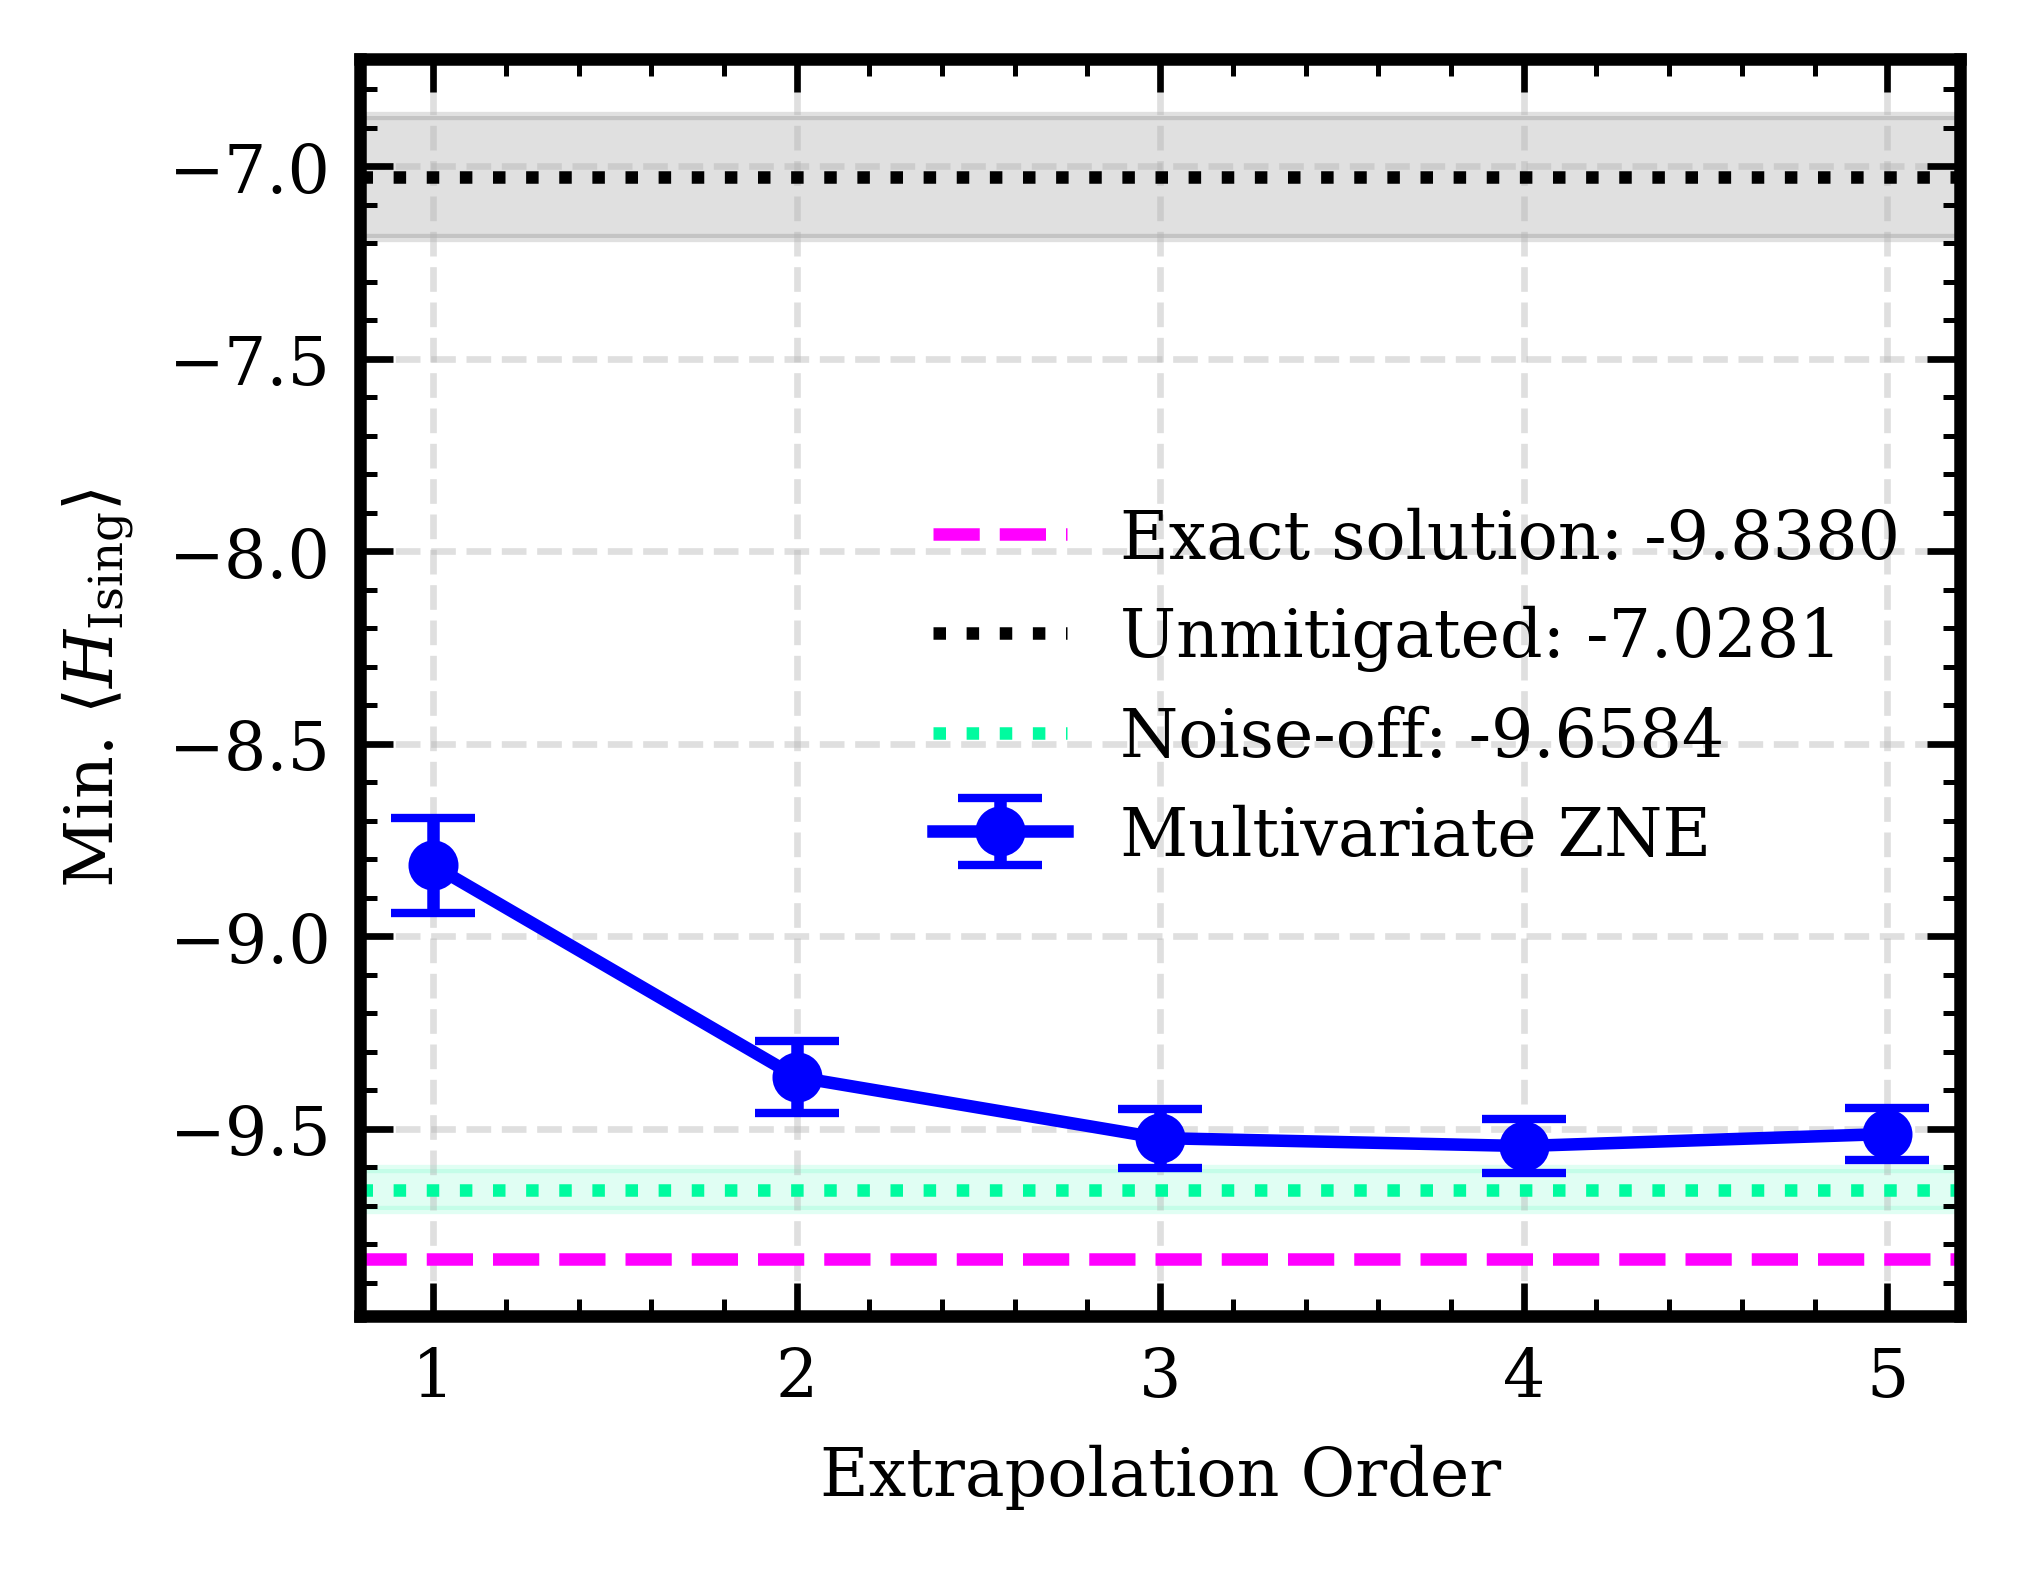

In [9]:
ricmul_plot_zne_vs_degree(
    processed_mul_var = PLOT_TARGET,
    plot_colors       = {"zne": "#0000ff", "noisy": "black",
                      "exact": "magenta", "noise_off": "#00fb9f", "unmitigated": "black"},
    plot_file_name    = f"multivar_zne_{nqubits}q_{noise_type}",
    zne_label = "Multivariate ZNE",
    output_dir        = REPORT_DIR,
    exact_sol         = exact_sol,
    #figure_title = "Dephasing Noise",
    annotate_cost     = False,
    save_format       = "png",
    show_plot      = False,
    dpi                   = 600,
    figsize               = (3.25, 2.5),
    tick_fontsize  = 8,
    label_fontsize = 8,
    capsize  = 5,
    marker_size  = 5,
    border_width  = 1.5,
    ylabel = r"Min. $\langle H_{\text{Ising}} \rangle$"
)

In [10]:
PROCESSED_SIM_DATA[_QSYSTEM]["ZNE-mul-var"]

{'muld2': {'noise_type': 'time-depol',
  'tmax': 20.0,
  'exact_sol': -9.837951447459421,
  'sorted_noise': [[4, 1, 1],
   [36, 3, 3],
   [36, 5, 3],
   [52, 3, 3],
   [52, 5, 3],
   [60, 3, 5],
   [60, 5, 5],
   [68, 3, 3],
   [84, 3, 7],
   [92, 3, 5]],
  'mean_exp_vals': [-7.028104805115262,
   -2.5390296565544546,
   -1.9558828028255948,
   -1.9303016470129193,
   -1.4914320168930462,
   -1.4070386345833887,
   -1.0892126388654333,
   -1.4765323081298236,
   -0.8011788748589364,
   -0.8389561390317279],
  'std_exp_vals': [0.158371805293024,
   0.21469738938796737,
   0.2127062195697065,
   0.19610188423227534,
   0.18629075582729906,
   0.1618682592087909,
   0.14980780636909,
   0.17541641179997858,
   0.11777616040892143,
   0.12580852545772472],
  'zne_mean': -9.365709494803022,
  'zne_std': 0.09252120925043855,
  'mean_noise_off': -9.65844800304873,
  'std_noise_off': 0.05286937954035172,
  'degree': 2,
  'order': 2,
  'eta_mean': [1.8749999999999905,
   -4.296874999999985,
   

## ZNE Table

Saved EPS -> reports/8Q-ising-depol/zne_order_table.eps  |  width=3.5000 in  dpi=600
Saved PNG -> reports/8Q-ising-depol/zne_order_table.png  |  2100x540 px  (3.5000 x 0.9000 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Order 1 & $-8.816 \pm 0.124$ \\
        Order 2 & $-9.366 \pm 0.093$ \\
        Order 3 & $-9.524 \pm 0.076$ \\
        Order 4 & $-9.545 \pm 0.070$ \\
        Order 5 & $-9.514 \pm 0.068$ \\
        \hline
------------------------



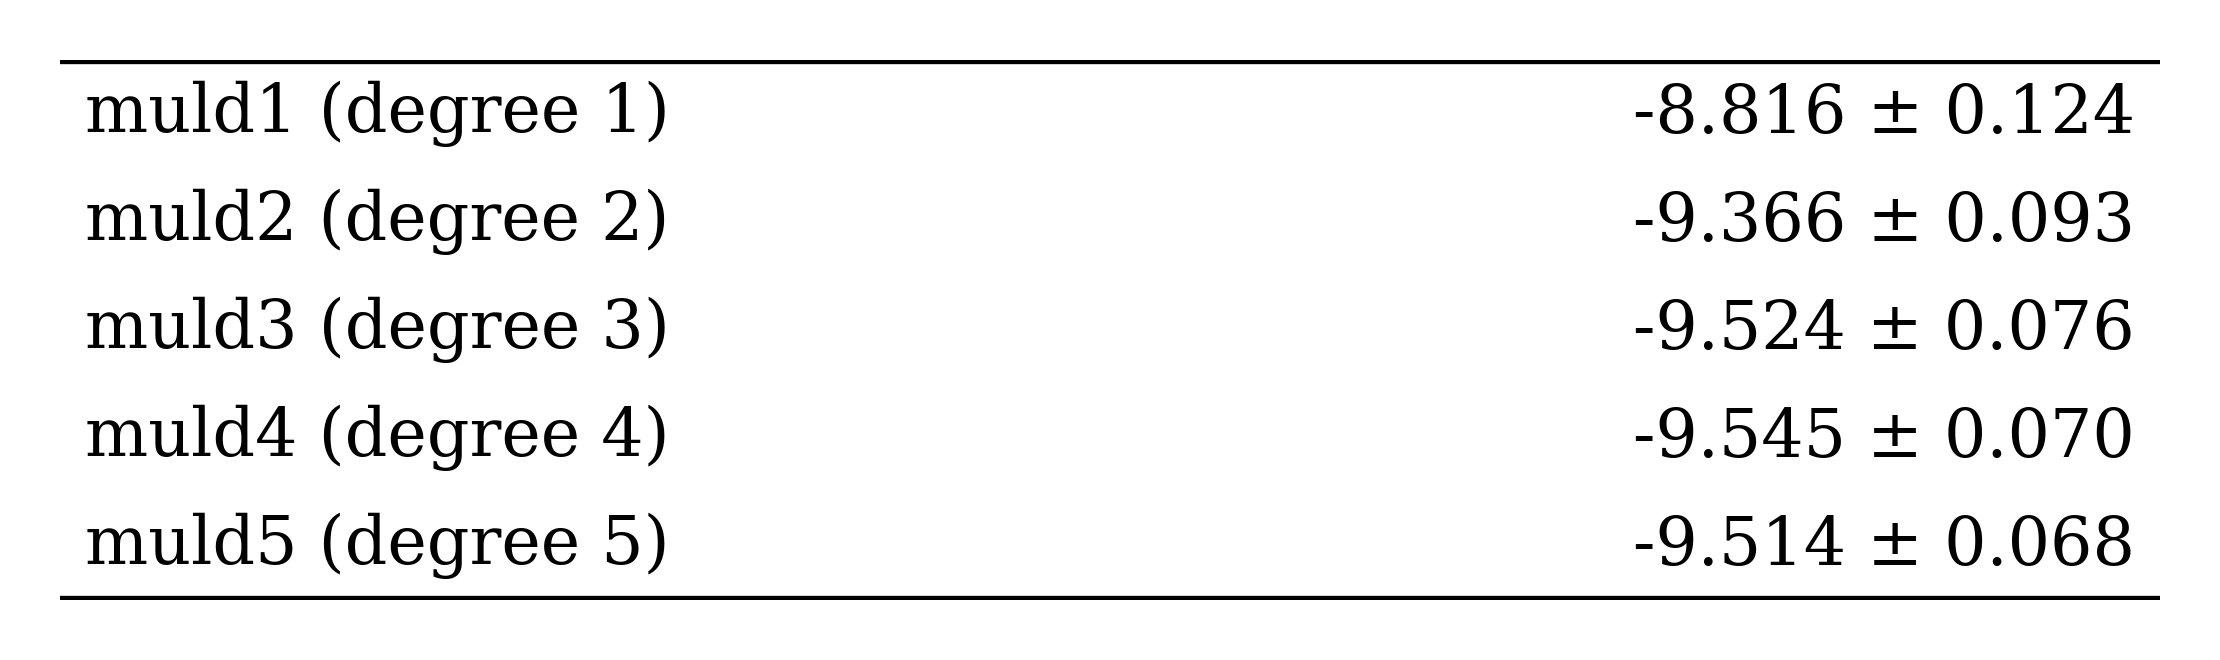

In [11]:
make_zne_order_table(PROCESSED_SIM_DATA[_QSYSTEM]["ZNE-mul-var"], output_dir=REPORT_DIR, filename_stem="zne_order_table", fontsize=8, row_height=0.18, fig_width=3.5, dpi=600)

### Degree 1


--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-9.658 \pm 0.053 $\\
        \hline
        At base noise $= [4, 1, 1]$ & $-7.028 \pm 0.158 $\\
        At boosted noise $= [36, 3, 3]$ & $-2.539 \pm 0.215 $\\
        At boosted noise $= [52, 3, 3]$ & $-1.930 \pm 0.196 $\\
        At boosted noise $= [60, 3, 5]$ & $-1.407 \pm 0.162 $\\
        \hline
        \text{Multivariate Richardson ZNE value} & $-8.816 \pm 0.124$ \\
        \hline
------------------------



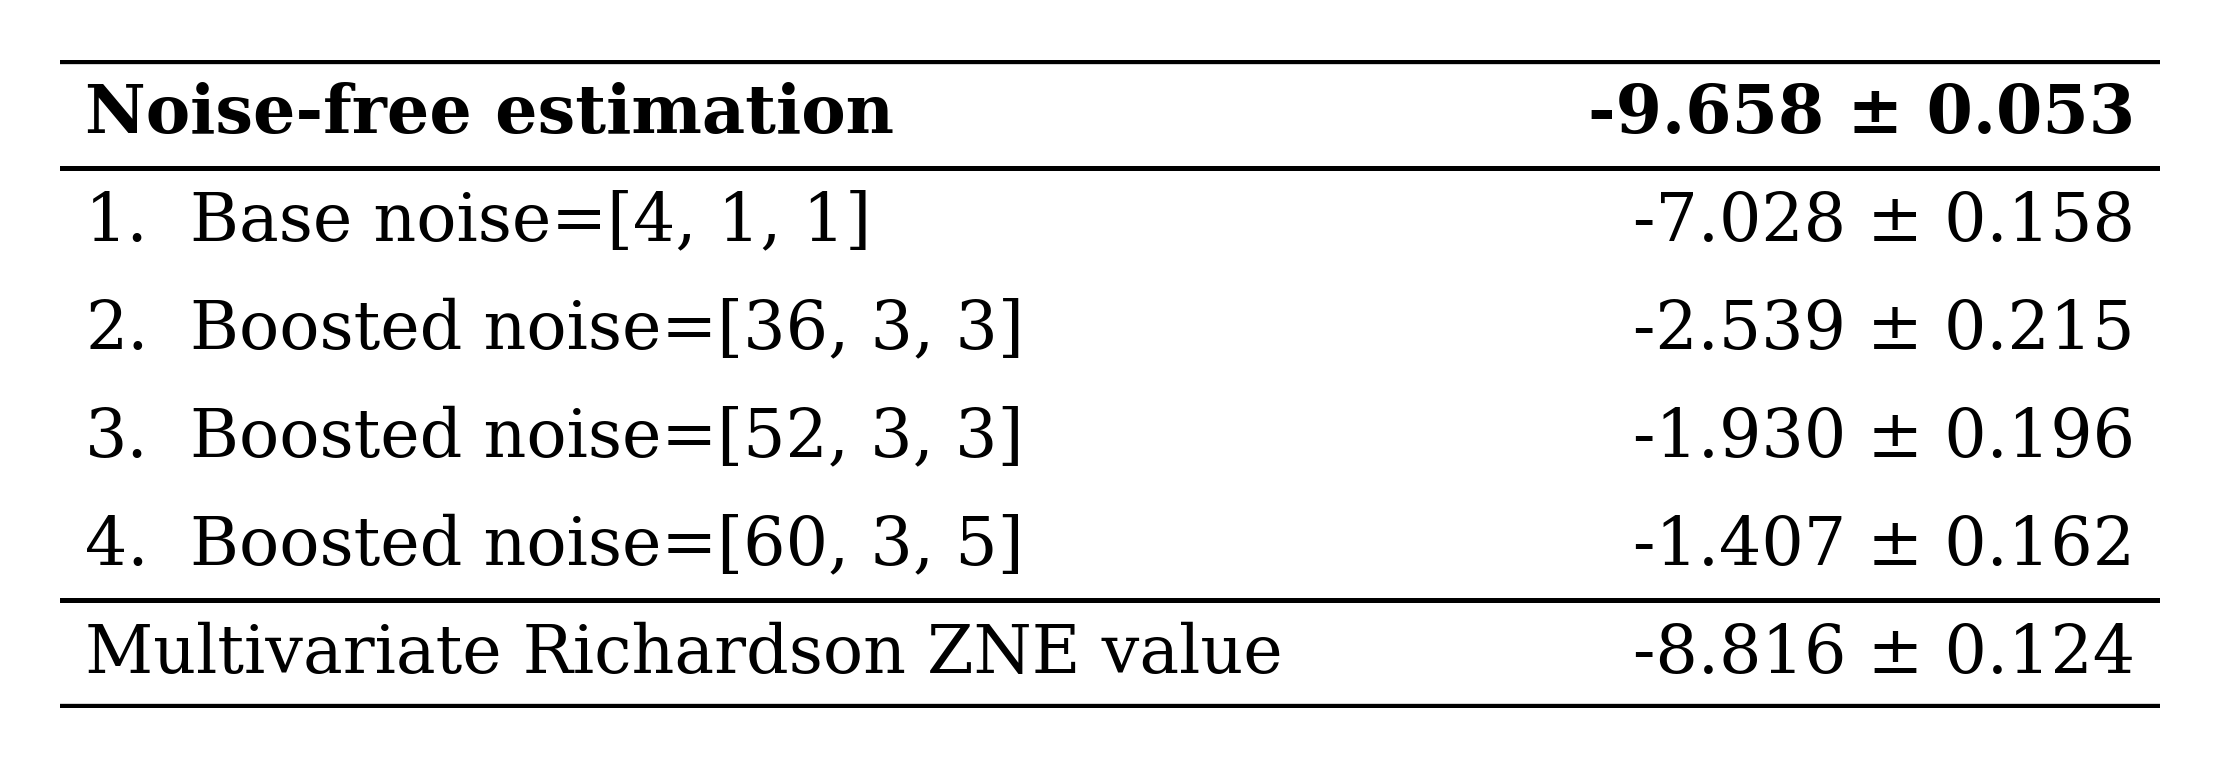

In [12]:
make_multivatiate_zne_table(TARGET_ZNE_TABLE["muld1"], output_dir=REPORT_DIR, save_eps=False, save_png=False, fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

### Degree 2


--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-9.658 \pm 0.053 $\\
        \hline
        At base noise $= [4, 1, 1]$ & $-7.028 \pm 0.158 $\\
        At boosted noise $= [36, 3, 3]$ & $-2.539 \pm 0.215 $\\
        At boosted noise $= [36, 5, 3]$ & $-1.956 \pm 0.213 $\\
        At boosted noise $= [52, 3, 3]$ & $-1.930 \pm 0.196 $\\
        At boosted noise $= [52, 5, 3]$ & $-1.491 \pm 0.186 $\\
        At boosted noise $= [60, 3, 5]$ & $-1.407 \pm 0.162 $\\
        At boosted noise $= [60, 5, 5]$ & $-1.089 \pm 0.150 $\\
        At boosted noise $= [68, 3, 3]$ & $-1.477 \pm 0.175 $\\
        At boosted noise $= [84, 3, 7]$ & $-0.801 \pm 0.118 $\\
        At boosted noise $= [92, 3, 5]$ & $-0.839 \pm 0.126 $\\
        \hline
        \text{Multivariate Richardson ZNE value} & $-9.366 \pm 0.093$ \\
        \hline
------------------------



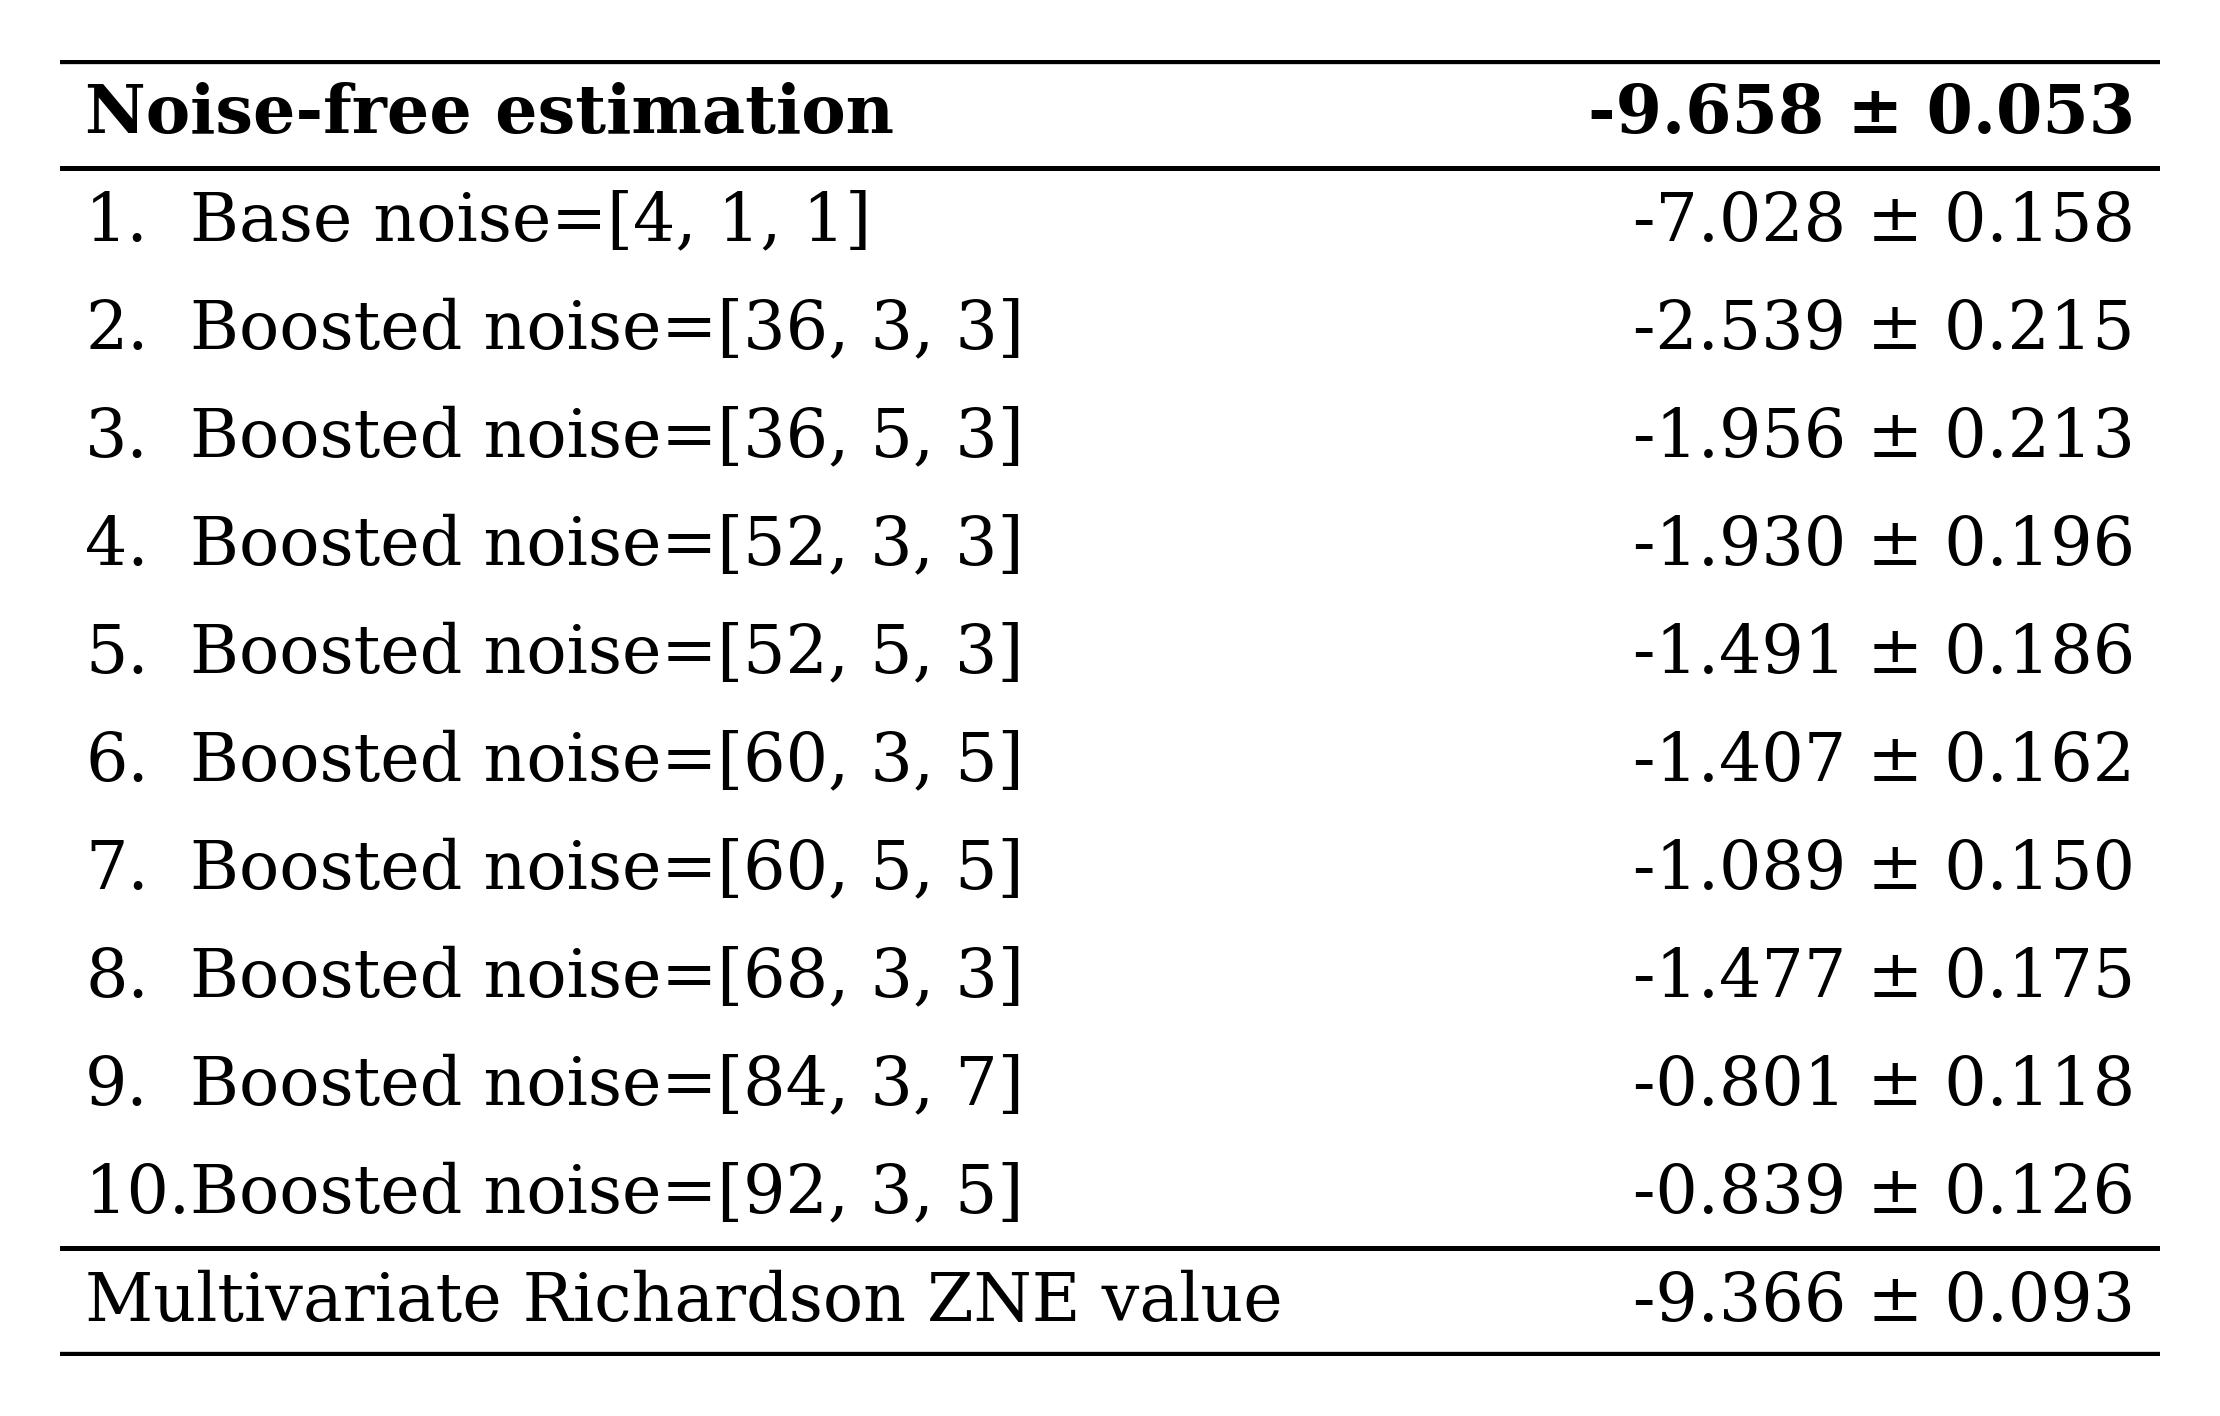

In [13]:
make_multivatiate_zne_table(TARGET_ZNE_TABLE["muld2"], output_dir=REPORT_DIR, save_eps=False, save_png=False, fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

### Degree 3


--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-9.658 \pm 0.053 $\\
        \hline
        At base noise $= [4, 1, 1]$ & $-7.028 \pm 0.158 $\\
        At boosted noise $= [36, 3, 3]$ & $-2.539 \pm 0.215 $\\
        At boosted noise $= [36, 5, 3]$ & $-1.956 \pm 0.213 $\\
        At boosted noise $= [36, 7, 3]$ & $-1.521 \pm 0.206 $\\
        At boosted noise $= [52, 3, 3]$ & $-1.930 \pm 0.196 $\\
        At boosted noise $= [52, 5, 3]$ & $-1.491 \pm 0.186 $\\
        At boosted noise $= [52, 7, 3]$ & $-1.162 \pm 0.176 $\\
        At boosted noise $= [60, 3, 5]$ & $-1.407 \pm 0.162 $\\
        At boosted noise $= [60, 5, 5]$ & $-1.089 \pm 0.150 $\\
        At boosted noise $= [60, 7, 5]$ & $-0.849 \pm 0.139 $\\
        At boosted noise $= [68, 3, 3]$ & $-1.477 \pm 0.175 $\\
        At boosted noise $= [68, 5, 3]$ & $-1.144 \pm 0.162 $\\
        At boosted noise $= [84, 3, 3]$ & $-1.136 \pm 0.155 $\\
        At boosted noise $= [84, 3, 7]$ & $-0.801 \pm 0.118 $\\
      

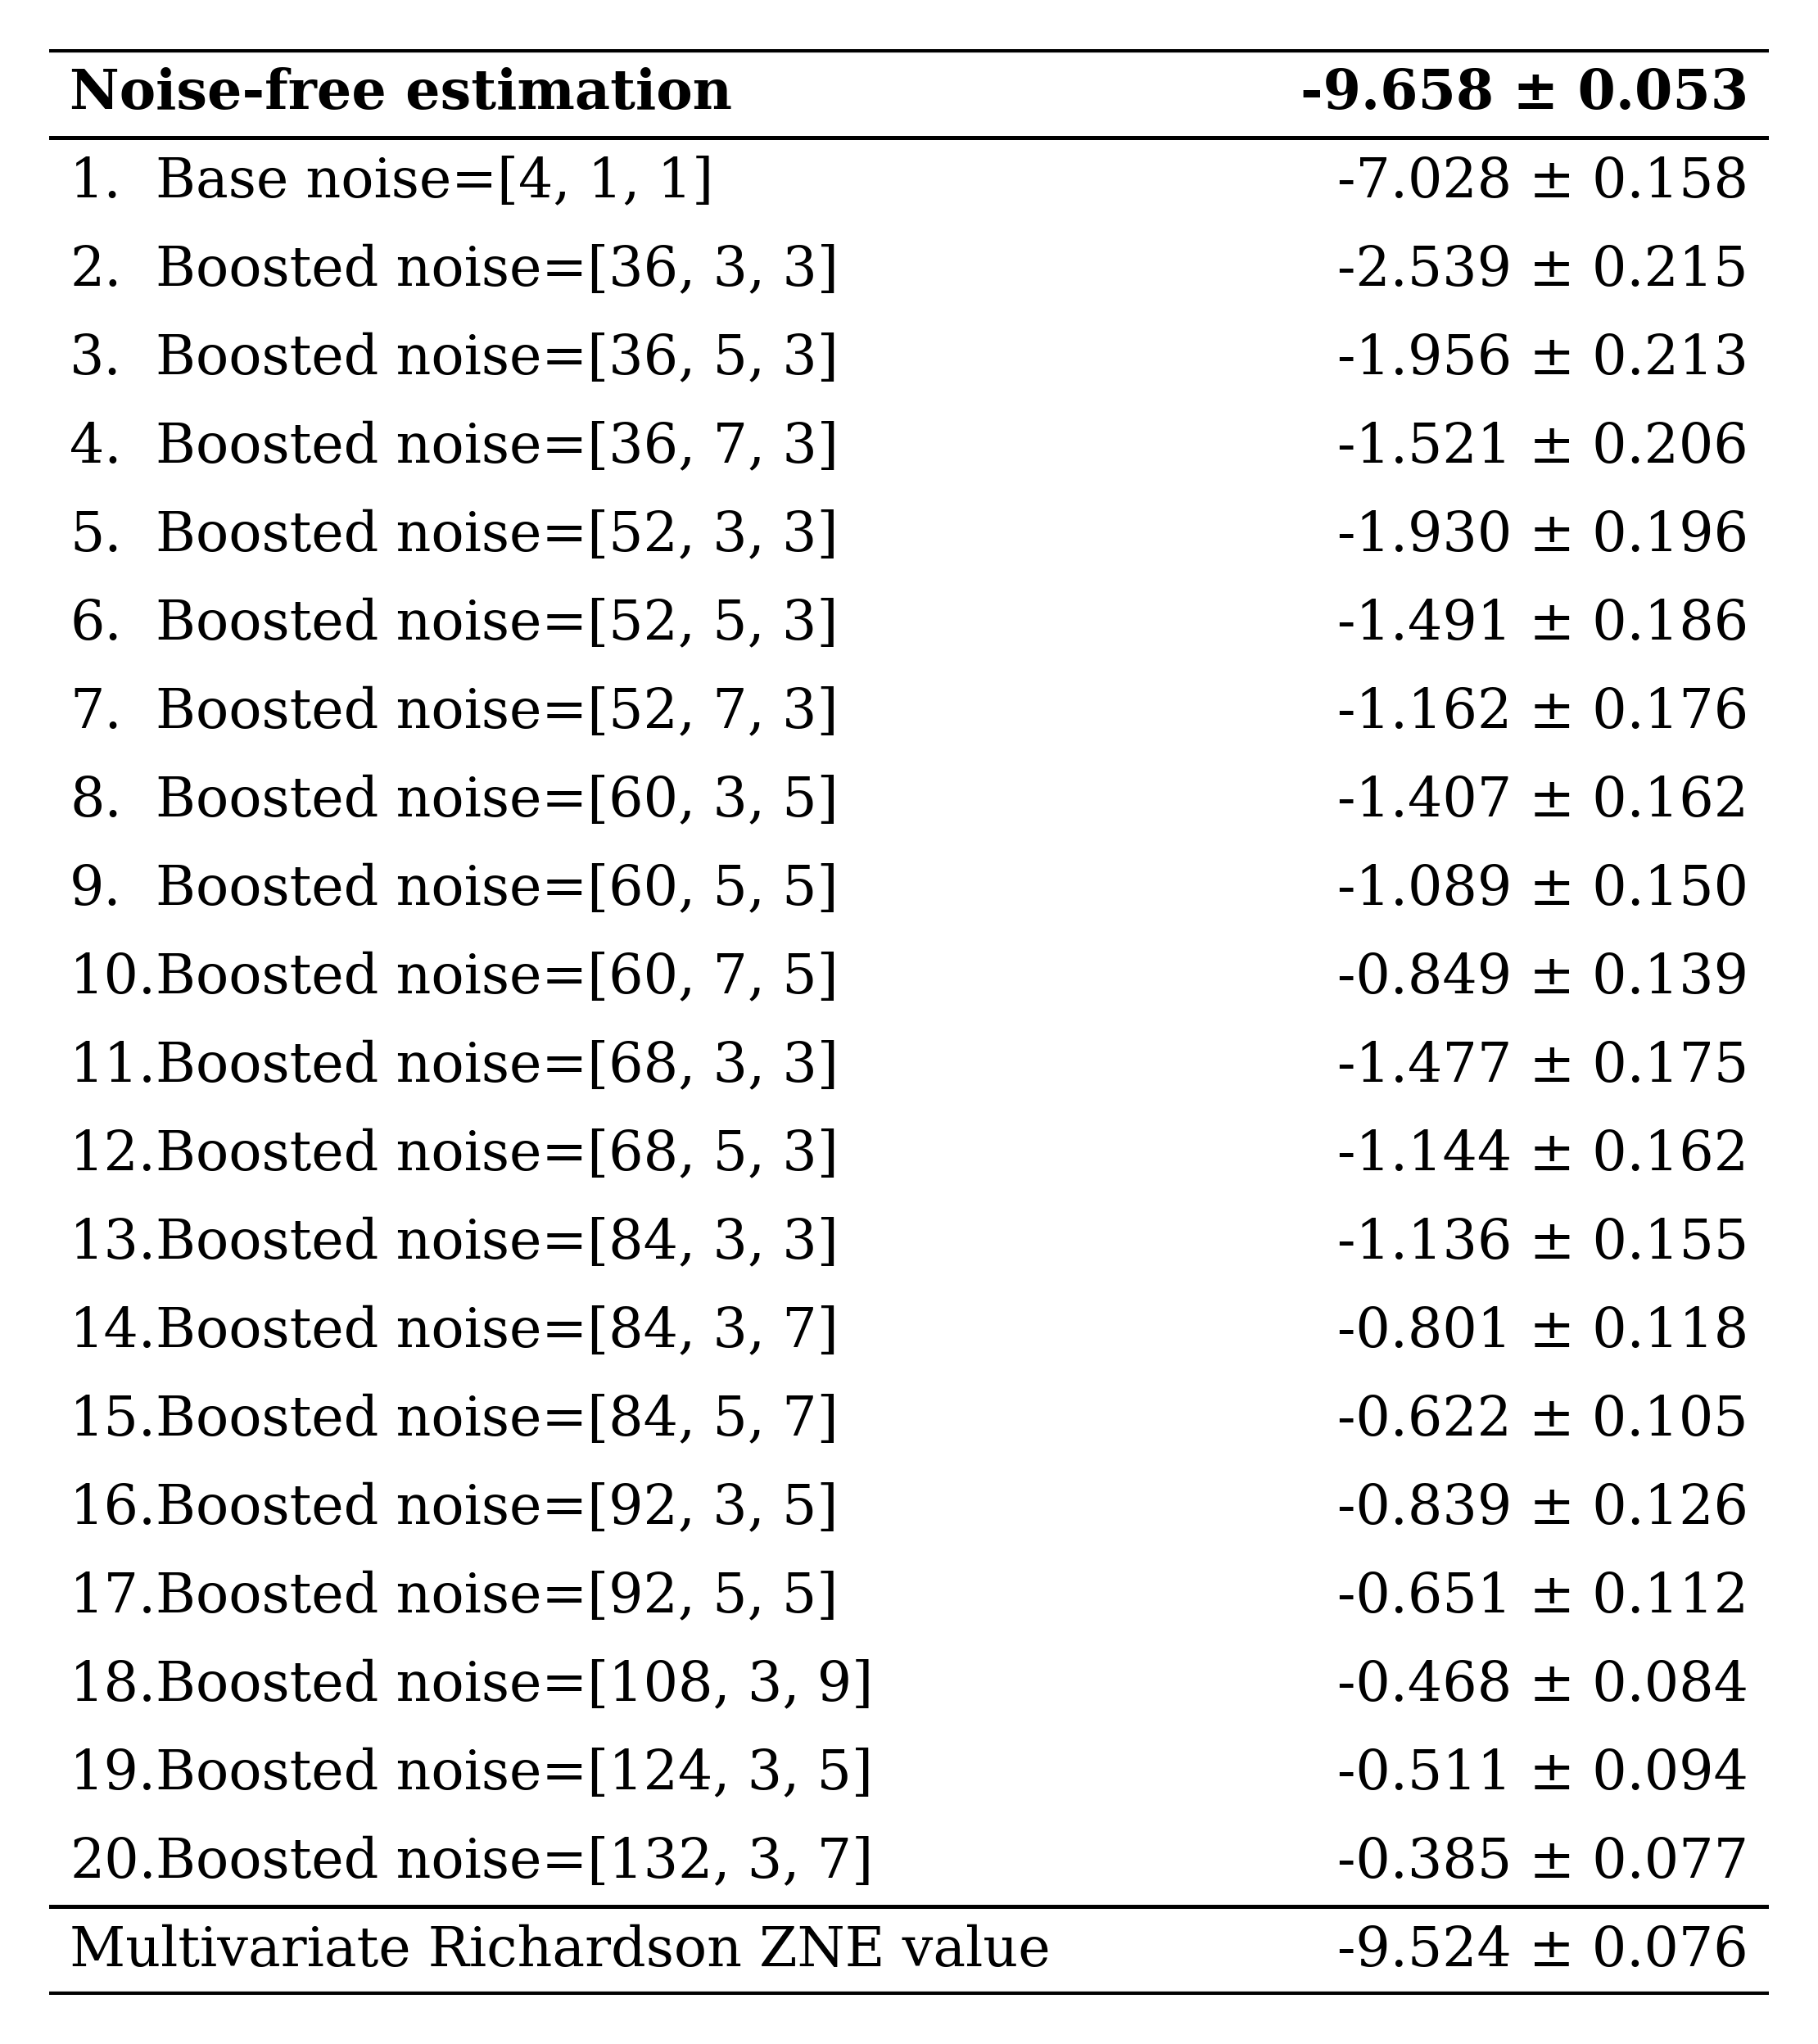

In [14]:
make_multivatiate_zne_table(TARGET_ZNE_TABLE["muld3"], output_dir=REPORT_DIR, save_eps=False, save_png=False, fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

### Degree 4


--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-9.658 \pm 0.053 $\\
        \hline
        At base noise $= [4, 1, 1]$ & $-7.028 \pm 0.158 $\\
        At boosted noise $= [36, 3, 3]$ & $-2.539 \pm 0.215 $\\
        At boosted noise $= [36, 5, 3]$ & $-1.956 \pm 0.213 $\\
        At boosted noise $= [36, 7, 3]$ & $-1.521 \pm 0.206 $\\
        At boosted noise $= [36, 9, 3]$ & $-1.191 \pm 0.198 $\\
        At boosted noise $= [52, 3, 3]$ & $-1.930 \pm 0.196 $\\
        At boosted noise $= [52, 5, 3]$ & $-1.491 \pm 0.186 $\\
        At boosted noise $= [52, 7, 3]$ & $-1.162 \pm 0.176 $\\
        At boosted noise $= [52, 9, 3]$ & $-0.911 \pm 0.166 $\\
        At boosted noise $= [60, 3, 5]$ & $-1.407 \pm 0.162 $\\
        At boosted noise $= [60, 5, 5]$ & $-1.089 \pm 0.150 $\\
        At boosted noise $= [60, 7, 5]$ & $-0.849 \pm 0.139 $\\
        At boosted noise $= [68, 3, 3]$ & $-1.477 \pm 0.175 $\\
        At boosted noise $= [60, 9, 5]$ & $-0.665 \pm 0.129 $\\
      

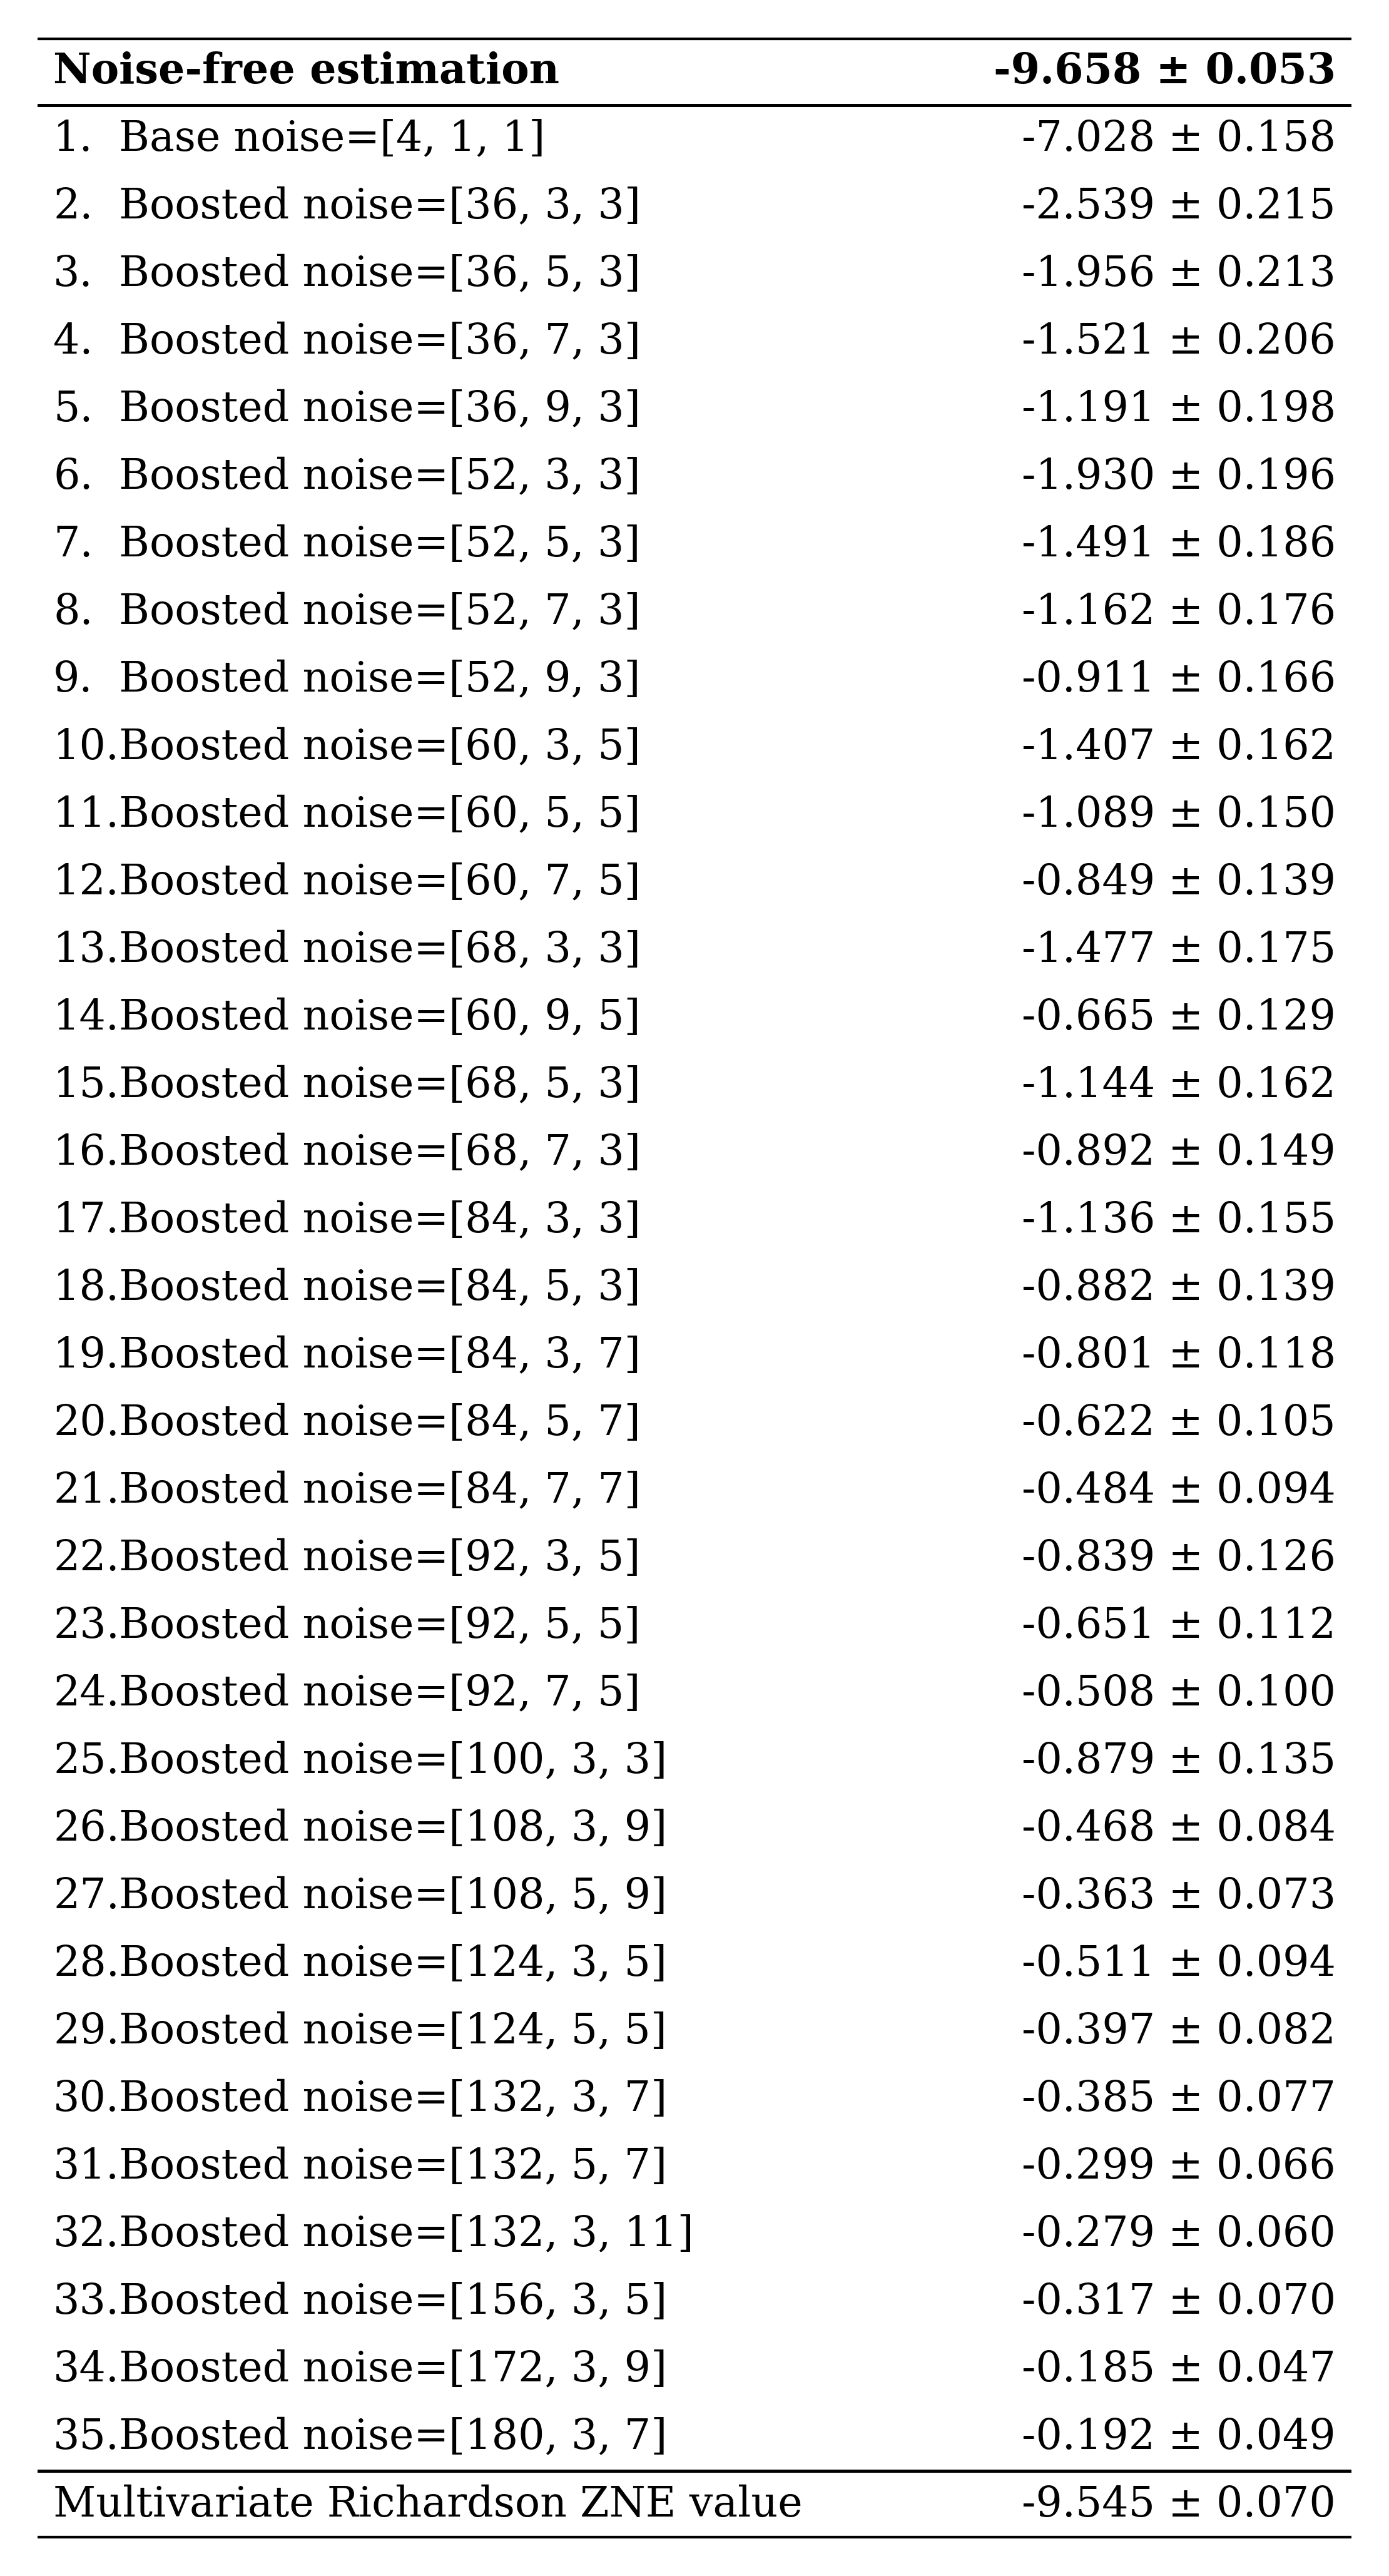

In [15]:
make_multivatiate_zne_table(TARGET_ZNE_TABLE["muld4"], output_dir=REPORT_DIR, save_eps=False, save_png=False, fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

### Degree 5


--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-9.658 \pm 0.053 $\\
        \hline
        At base noise $= [4, 1, 1]$ & $-7.028 \pm 0.158 $\\
        At boosted noise $= [36, 3, 3]$ & $-2.539 \pm 0.215 $\\
        At boosted noise $= [36, 5, 3]$ & $-1.956 \pm 0.213 $\\
        At boosted noise $= [36, 7, 3]$ & $-1.521 \pm 0.206 $\\
        At boosted noise $= [36, 9, 3]$ & $-1.191 \pm 0.198 $\\
        At boosted noise $= [36, 11, 3]$ & $-0.938 \pm 0.189 $\\
        At boosted noise $= [52, 3, 3]$ & $-1.930 \pm 0.196 $\\
        At boosted noise $= [52, 5, 3]$ & $-1.491 \pm 0.186 $\\
        At boosted noise $= [52, 7, 3]$ & $-1.162 \pm 0.176 $\\
        At boosted noise $= [52, 9, 3]$ & $-0.911 \pm 0.166 $\\
        At boosted noise $= [52, 11, 3]$ & $-0.716 \pm 0.156 $\\
        At boosted noise $= [60, 3, 5]$ & $-1.407 \pm 0.162 $\\
        At boosted noise $= [60, 5, 5]$ & $-1.089 \pm 0.150 $\\
        At boosted noise $= [60, 7, 5]$ & $-0.849 \pm 0.139 $\\
    

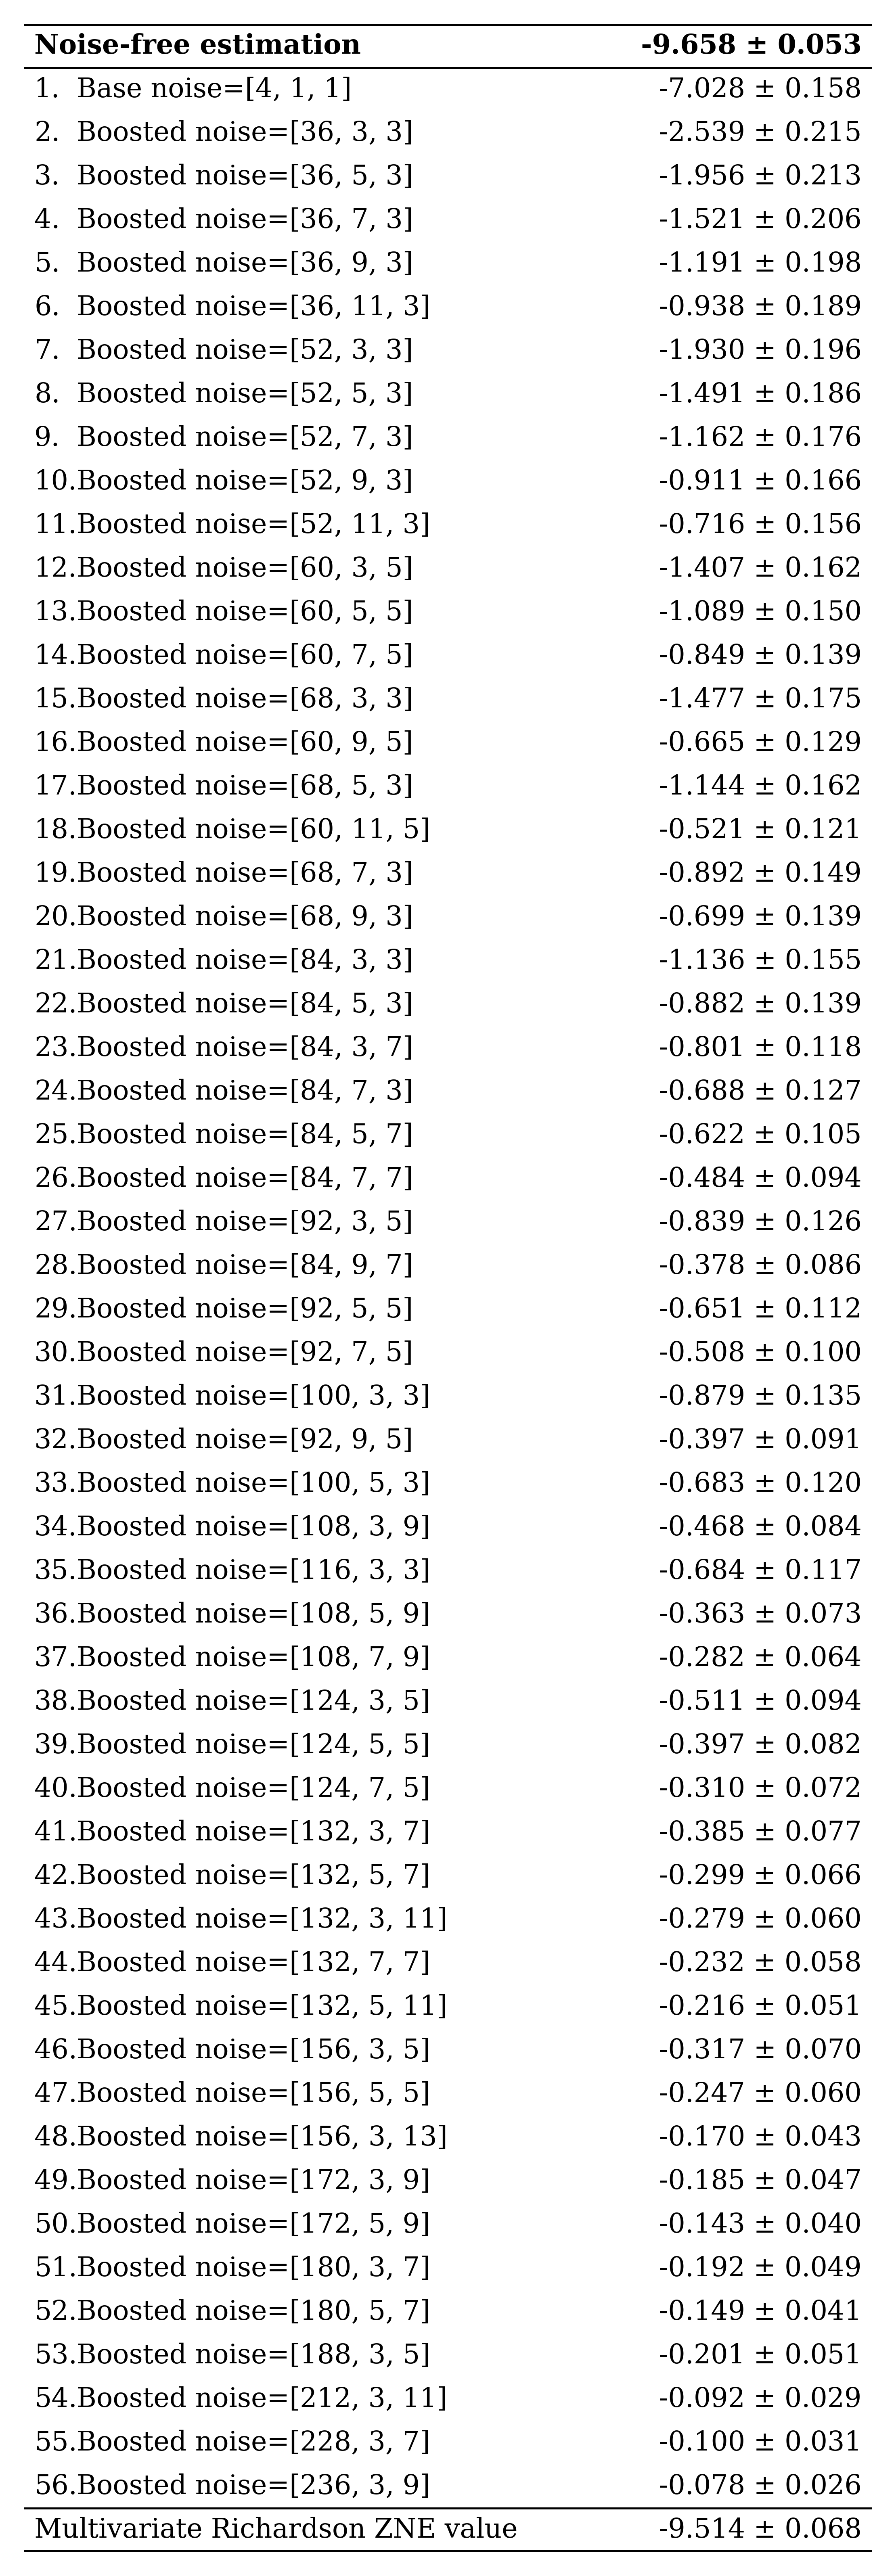

In [16]:
make_multivatiate_zne_table(TARGET_ZNE_TABLE["muld5"], output_dir=REPORT_DIR, save_eps=False, save_png=False, fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

---

# ✅ Additional Analysis

## Sampling Overhead



In [17]:
zne_data = PROCESSED_SIM_DATA[_QSYSTEM]["ZNE-mul-var"]

sampling_overhead_eq_by_order = {
    order: len(zne_data[f"muld{order}"]["eta_mean"])
           * sum(abs(e) ** 2 for e in zne_data[f"muld{order}"]["eta_mean"])
    for order in [1, 2, 3, 4, 5]
    if zne_data.get(f"muld{order}", {}).get("eta_mean")
}
print(f"Sampling overhead (equal shot allocation): {sampling_overhead_eq_by_order}")

sampling_overhead_opt_by_order = {
    order: sum(abs(e) for e in zne_data[f"muld{order}"]["eta_mean"]) ** 2
    for order in [1, 2, 3, 4, 5]
    if zne_data.get(f"muld{order}", {}).get("eta_mean")
}
print(f"Sampling overhead (optimal shot allocation): {sampling_overhead_opt_by_order}")

Sampling overhead (equal shot allocation): {1: 17.500000000000004, 2: 351.3818359374983, 3: 4348.9699130587005, 4: 38714.73874038835, 5: 315496.1080048842}
Sampling overhead (optimal shot allocation): {1: 12.25, 2: 165.76562499999918, 3: 1614.4072875976015, 4: 12941.062088941128, 5: 98482.74544026295}


## 🌟 Plot: Multi-Variate ZNE Overhead

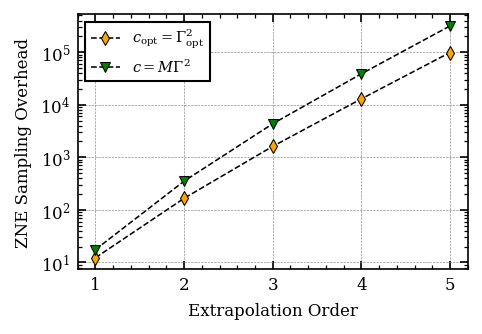

In [18]:
# Sort orders to keep x-axis consistent
orders = sorted(sampling_overhead_opt_by_order.keys())

if not orders:
    raise ValueError("No valid orders found to plot.")

y_opt = [sampling_overhead_opt_by_order[o] for o in orders]
y_eq  = [sampling_overhead_eq_by_order[o]  for o in orders]

plt.figure(figsize=(3.25, 2.5), dpi=150)

plt.errorbar(
    orders, y_opt,
    fmt='d', linestyle='--', color='black',
    linewidth=0.75, capsize=5, markersize=5,
    markerfacecolor='orange', markeredgecolor='black', markeredgewidth=0.5,
    label=r'$c_{\mathrm{opt}} = \Gamma_{\mathrm{opt}}^2$'
)
plt.errorbar(
    orders, y_eq,
    fmt='v', linestyle='--', color='black',
    linewidth=0.75, capsize=5, markersize=5,
    markerfacecolor='green', markeredgecolor='black', markeredgewidth=0.5,
    label=r'$c = M\Gamma^2$'
)

plt.yscale('log')
plt.xlabel('Extrapolation Order', fontsize=8)
plt.ylabel(r'ZNE Sampling Overhead', fontsize=8)
plt.legend(
    fontsize=7, loc='upper left',
    framealpha=1.0, edgecolor='black', fancybox=False
)
plt.grid(True, color='grey', linestyle='--', linewidth=0.3)
plt.subplots_adjust(left=0.18, right=0.98, top=0.88, bottom=0.20)

os.makedirs(REPORT_DIR, exist_ok=True)
plt.savefig(os.path.join(REPORT_DIR, f"zne_overhead_{nqubits}q_{noise_type}.png"), format="png", dpi=600)
plt.show()
plt.close()

In [19]:
zne_overhead_stats = {
    order: {
        "cost_opt":     sampling_overhead_opt_by_order[order],
        "cost_opt_std": None,
        "cost_eq":      sampling_overhead_eq_by_order[order],
        "cost_eq_std":  None,
    }
    for order in orders
}

zne_overhead_stats

{1: {'cost_opt': 12.25,
  'cost_opt_std': None,
  'cost_eq': 17.500000000000004,
  'cost_eq_std': None},
 2: {'cost_opt': 165.76562499999918,
  'cost_opt_std': None,
  'cost_eq': 351.3818359374983,
  'cost_eq_std': None},
 3: {'cost_opt': 1614.4072875976015,
  'cost_opt_std': None,
  'cost_eq': 4348.9699130587005,
  'cost_eq_std': None},
 4: {'cost_opt': 12941.062088941128,
  'cost_opt_std': None,
  'cost_eq': 38714.73874038835,
  'cost_eq_std': None},
 5: {'cost_opt': 98482.74544026295,
  'cost_opt_std': None,
  'cost_eq': 315496.1080048842,
  'cost_eq_std': None}}

## Multivar ZNE with Sampling Overhead Latex Table

Checking consistency

In [20]:
# _target = PROCESSED_SIM_DATA[_QSYSTEM]["ZNE-mul-var"]

# # Build a reference dict keyed by order from the per-run-averaged stats
# reference_stats = {}
# for item in _target:
#     order = _target[item]["order"]
#     if order is None or order == "N/A":
#         continue
#     reference_stats[order] = {
#         "cost_opt": _target[item]["cost_opt_mean"],
#         "cost_eq":  _target[item]["cost_eq_mean"],
#     }

# # Compare against zne_overhead_stats (eta_mean-derived)
# print(f"{'Order':>5} | {'cost_opt (eta_mean)':>20} | {'cost_opt (per-run avg)':>22} | {'match':>5} | "
#       f"{'cost_eq (eta_mean)':>19} | {'cost_eq (per-run avg)':>21} | {'match':>5}")

# for order in sorted(zne_overhead_stats.keys()):
#     if order not in reference_stats:
#         print(f"⚠️ Order {order}: no reference value found in PROCESSED_SIM_DATA, skipping.")
#         continue

#     eta_opt = zne_overhead_stats[order]["cost_opt"]
#     ref_opt = reference_stats[order]["cost_opt"]
#     eta_eq  = zne_overhead_stats[order]["cost_eq"]
#     ref_eq  = reference_stats[order]["cost_eq"]

#     match_opt = "✅" if (eta_opt is not None and ref_opt is not None and np.isclose(eta_opt, ref_opt, rtol=1e-2)) else "❌"
#     match_eq  = "✅" if (eta_eq  is not None and ref_eq  is not None and np.isclose(eta_eq,  ref_eq,  rtol=1e-2)) else "❌"

#     print(f"{order:>5} | {eta_opt:>20.6f} | {ref_opt:>22.6f} | {match_opt:>5} | "
#           f"{eta_eq:>19.6f} | {ref_eq:>21.6f} | {match_eq:>5}")

In [21]:
print(make_zne_order_table_latex(zne_data))

\begin{table}
\caption{\textbf{Multivariate ZNE in plot Figure \ref{fig-plots-zne-diff-orders-multivariate}. Mean values and corresponding standard deviations are computed over 10 independent experimental runs.}}
\label{table-multi-var-zne}
\setlength{\tabcolsep}{3pt}
\begin{tabular}{|p{71pt}|p{71pt}|p{71pt}|}
\hline
Quantity & Estimated Value (Mean $\pm$ Std. Dev.) & ZNE Sampling Overhead $(c)$ \\
\hline
Noise-free estimation & $-9.658 \pm 0.053$ & -- \\
\hline
Unmitigated & $-7.028 \pm 0.158$ & -- \\
\hline
ZNE of order 1 & $-8.816 \pm 0.124$ & $1.75 \times 10^{1}$ \\
ZNE of order 2 & $-9.366 \pm 0.093$ & $3.51 \times 10^{2}$ \\
ZNE of order 3 & $-9.524 \pm 0.076$ & $4.35 \times 10^{3}$ \\
ZNE of order 4 & $-9.545 \pm 0.070$ & $3.87 \times 10^{4}$ \\
ZNE of order 5 & $-9.514 \pm 0.068$ & $3.15 \times 10^{5}$ \\
\hline
\multicolumn{3}{p{215pt}}{All values are expressed in dimensionless units. Due to the large number of data points, we do not include them explicitly here. For more deta

---

## Circuit-dpeth Overhead

In [22]:
zne_data = PROCESSED_SIM_DATA[_QSYSTEM]["ZNE-mul-var"]

GATE_COUNTS = {}
for label, entry in zne_data.items():
    order = entry.get("order")
    raw_gate_counts = entry.get("raw_gate_counts")

    if order is None or order == "N/A":
        print(f"⚠️ GATE_COUNTS: skipping {label}, no valid order/degree found.")
        continue
    if raw_gate_counts is None:
        print(f"⚠️ GATE_COUNTS: skipping {label} (order={order}), no raw_gate_counts found.")
        continue

    if order in GATE_COUNTS:
        print(f"❌ GATE_COUNTS: duplicate order={order} found (labels '{label}' and a previous one) — overwriting.")

    GATE_COUNTS[order] = raw_gate_counts

GATE_COUNTS

{2: [{'identity_factors': [0, 0, 0, 0],
   'raw_gate_count': {'R': 4, 'CZ': 1, 'U': 1, 'Y': 0, 'total': 6}},
  {'identity_factors': [1, 1, 1, 1],
   'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 3, 'Y': 24, 'total': 42}},
  {'identity_factors': [1, 1, 1, 2],
   'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 3, 'Y': 40, 'total': 58}},
  {'identity_factors': [1, 1, 1, 3],
   'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 3, 'Y': 56, 'total': 74}},
  {'identity_factors': [1, 1, 2, 1],
   'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 5, 'Y': 48, 'total': 68}},
  {'identity_factors': [1, 1, 2, 2],
   'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 5, 'Y': 80, 'total': 100}},
  {'identity_factors': [1, 1, 3, 1],
   'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 7, 'Y': 72, 'total': 94}},
  {'identity_factors': [1, 2, 1, 1],
   'raw_gate_count': {'R': 12, 'CZ': 5, 'U': 3, 'Y': 24, 'total': 44}},
  {'identity_factors': [1, 2, 1, 2],
   'raw_gate_count': {'R': 12, 'CZ': 5, 'U': 3, 'Y': 40, 'total': 60}},
  {'identity_facto

In [23]:
# Total number of gate operation per layer across all circuits for each ZNE order
total_gates_per_layer_by_zne_order = {
    order: sum(circuit["raw_gate_count"]["total"] for circuit in circuits)
    for order, circuits in GATE_COUNTS.items()
}
print(f"Total gates per layer by ZNE order: {total_gates_per_layer_by_zne_order}")

Total gates per layer by ZNE order: {2: 616, 1: 174, 5: 6282, 3: 1554, 4: 3302}


### 🌟 Plot: Gate Counts (per layer) vs Extrapolation Order

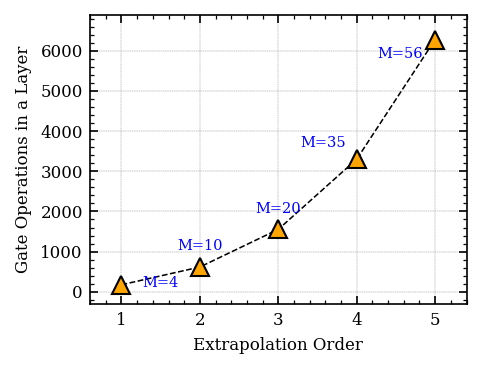

In [24]:
def plot_total_gates_vs_order(orders, totals, M_values, dpi=150, REPORT_DIR="."):
    fig, ax = plt.subplots(figsize=(3.25, 2.5), dpi=dpi)

    ax.plot(
        orders,
        totals,
        marker="^",
        linewidth=0.75,
        markersize=9,
        color="black",
        linestyle="--",
        markerfacecolor="orange",
        markeredgecolor="black",
        markeredgewidth=1.0
        )

    # Manually tuned offsets (dx, dy in points) and alignment per point,
    # chosen based on the local slope of the curve so labels don't cross the line
    label_offsets = {
        1: ((10, 1), "left"),     # push right, curve rises steeply after this point
        2: ((0, 10), "center"),   # plenty of room above
        3: ((0, 10), "center"),   # plenty of room above
        4: ((-5, 8), "right"),   # push left/up to avoid the steep line to point 5
        5: ((-6, -7), "right"),  # last point: put label just below-left, inside the frame
    }

    for x, y, m in zip(orders, totals, M_values):
        (dx, dy), ha = label_offsets[x]
        ax.annotate(
            f"M={m}",
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=ha,
            va="center",
            fontsize=7,
            color="blue",
            clip_on=False,
            zorder = 5
        )

    ax.set_xlabel("Extrapolation Order", fontsize=8)
    ax.set_ylabel("Gate Operations in a Layer", fontsize=8)
    ax.set_xticks(orders)
    ax.grid(True, color='grey', linestyle='--', linewidth=0.2)

    # Generous margins so nothing gets clipped
    ax.set_xlim(min(orders) - 0.4, max(orders) + 0.4)
    y_range = max(totals) - min(totals)
    ax.set_ylim(min(totals) - 0.08 * y_range, max(totals) + 0.10 * y_range)

    #ax.set_yscale("log")
    fig.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, f"gatecounts_perlayer_{nqubits}q_{noise_type}.png"), format="png", dpi=dpi_600)
    plt.show()
    return fig


total_gates_per_layer_by_zne_order = {
    order: sum(circuit["raw_gate_count"]["total"] for circuit in circuits)
    for order, circuits in GATE_COUNTS.items()
}

orders = sorted(total_gates_per_layer_by_zne_order.keys())
totals = [total_gates_per_layer_by_zne_order[o] for o in orders]
M_values = [4, 10, 20, 35, 56]

fig = plot_total_gates_vs_order(orders, totals, M_values, REPORT_DIR=REPORT_DIR)

In [25]:
# Depth per layer across all circuits for each ZNE order
depth_per_layer_by_zne_order = {
    order: sum(
        (entry["raw_gate_count"]["R"] / 2)
        + entry["raw_gate_count"]["CZ"]
        + entry["raw_gate_count"]["U"]
        + (entry["raw_gate_count"]["Y"] / odd_sites_num)
        for entry in circuits
    )
    for order, circuits in GATE_COUNTS.items()
}
print(f"Depth per layer by ZNE order: {depth_per_layer_by_zne_order}")

Depth per layer by ZNE order: {2: 236.0, 1: 70.0, 5: 2188.0, 3: 574.0, 4: 1182.0}


### 🌟 Plot: Circuit Depth vs Extrapolation Order

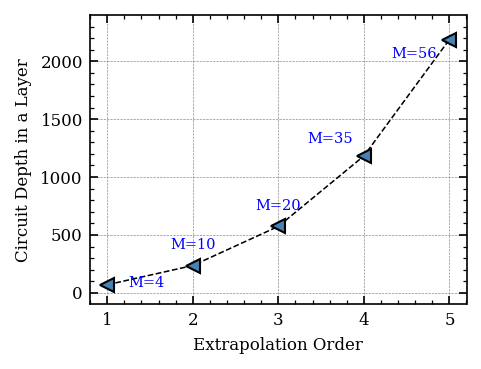

In [26]:
def plot_depth_vs_order(depths: dict, M_values: dict, dpi: int = 150, dpi_600: int = 600, REPORT_DIR: str = "."):
    """
    Plots circuit depth vs polynomial order.
    depths is keyed by integer ZNE order (1, 2, 3, ...).
    M_values maps order (int) to its corresponding M value for annotation.
    """
    orders = []
    depth_vals = []
    m_vals = []

    for order, depth in sorted(depths.items()):
        orders.append(order)
        depth_vals.append(depth)
        m_vals.append(M_values.get(order))

    fig, ax = plt.subplots(figsize=(3.25, 2.5), dpi=dpi)

    ax.plot(
        orders,
        depth_vals,
        marker="<",
        linewidth=0.75,
        markersize=7,
        color="black",
        linestyle="--",
        markerfacecolor="steelblue",
        markeredgecolor="black",
        markeredgewidth=1.0
        )

    # Manually tuned offsets (dx, dy in points) and alignment per point,
    # chosen based on the local slope of the curve so labels don't cross the line
    label_offsets = {
        1: ((10, 1), "left"),
        2: ((0, 10), "center"),
        3: ((0, 10), "center"),
        4: ((-5, 8), "right"),
        5: ((-6, -7), "right"),
    }

    for x, y, m in zip(orders, depth_vals, m_vals):
        (dx, dy), ha = label_offsets.get(x, ((0, 10), "center"))
        ax.annotate(
            f"M={m}",
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=ha,
            va="center",
            fontsize=7,
            color="blue",
            clip_on=False,
            zorder=5
        )

    ax.set_xlabel("Extrapolation Order", fontsize=8)
    ax.set_ylabel("Circuit Depth in a Layer", fontsize=8)
    ax.set_xticks(orders)
    ax.grid(True, color='grey', linestyle='--', linewidth=0.3)

    # Generous margins so labels don't get clipped
    y_range = max(depth_vals) - min(depth_vals)
    ax.set_ylim(min(depth_vals) - 0.08 * y_range, max(depth_vals) + 0.10 * y_range)

    #ax.set_yscale("log")
    fig.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, f"depth_perlayer_{nqubits}q_{noise_type}.png"), format="png", dpi=dpi_600)
    plt.show()
    return fig


M_values = {1: 4, 2: 10, 3: 20, 4: 35, 5: 56}
fig = plot_depth_vs_order(depth_per_layer_by_zne_order, M_values, REPORT_DIR=REPORT_DIR)

---

# ⏲ Runtime and Computational Cost

### Quantum Variance

In [27]:
# Read and parse the JSON data
with open(QV_FILE_PATH, "r") as f:
    qv_data = json.load(f)

summary = qv_data["summary"]

# Extract quantum variance values from summary (Hx, Hy, Hz, total)
QUANTUM_VAR_HX = summary.get("quantum_var_hx")
QUANTUM_VAR_HY = summary.get("quantum_var_hy")
QUANTUM_VAR_HZ = summary.get("quantum_var_hz")
QUANTUM_VAR_TOTAL = summary.get("quantum_var_total")
N_FILES = summary.get("n_files")

per_file_results = qv_data.get("per_file_results", [])
N_SAMPLES_TOTAL = sum(r.get("n_samples", 0) for r in per_file_results)

def fmt(val):
    return f"{val:.6e}" if val is not None else "N/A"

print(f"Quantum Variance (Hx):    {fmt(QUANTUM_VAR_HX)}")
print(f"Quantum Variance (Hy):    {fmt(QUANTUM_VAR_HY)}")
print(f"Quantum Variance (Hz):    {fmt(QUANTUM_VAR_HZ)}")
print(f"Quantum Variance (Total): {fmt(QUANTUM_VAR_TOTAL)}")
print(f"Number of files:          {N_FILES}")
print(f"Total number of samples:  {N_SAMPLES_TOTAL}")

Quantum Variance (Hx):    7.651336e+00
Quantum Variance (Hy):    N/A
Quantum Variance (Hz):    1.216851e+01
Quantum Variance (Total): 1.981985e+01
Number of files:          10
Total number of samples:  1171


### VQE Shots $s_u$ Estimation

In [28]:
# Target error precision
error_rate: float = 0.001
# Quantum variance shots (unmitigated)
shot_num_su: int = QUANTUM_VAR_TOTAL / (error_rate**2)
print(f"Shot number for Error {error_rate}: {shot_num_su:.0f} (≈ {shot_num_su/1e6:.2f} million shots)")

Shot number for Error 0.001: 19819848 (≈ 19.82 million shots)


## Runtime

In [29]:
# Total number of time evolution gates per layer across all circuits for each ZNE order
time_evo_gate_per_layer_by_zne_order = {
    order: sum(entry["raw_gate_count"]["U"]for entry in circuits)
    for order, circuits in GATE_COUNTS.items()
}
print(f"Time evolution gates per layer by ZNE order: {time_evo_gate_per_layer_by_zne_order}")

Time evolution gates per layer by ZNE order: {2: 38, 1: 12, 5: 306, 3: 88, 4: 173}


In [30]:
# Runtime for a ZNE order
runtime_by_zne_order = {
    order: t_opt_mean * grp_pauli  * (shot_num_su * sampling_overhead_eq_by_order[order]) * time_evo_gate_per_layer_by_zne_order[order]  for order in zne_overhead_stats
}
print(f"Estimated runtime by ZNE order (in seconds): {runtime_by_zne_order}")   

Estimated runtime by ZNE order (in seconds): {1: 159975678708.56924, 2: 10171794343898.32, 3: 291543754238927.25, 4: 5102195584958150.0, 5: 7.354448298307611e+16}


#### 🌟 Plot: Runtime vs Extrapolation Order

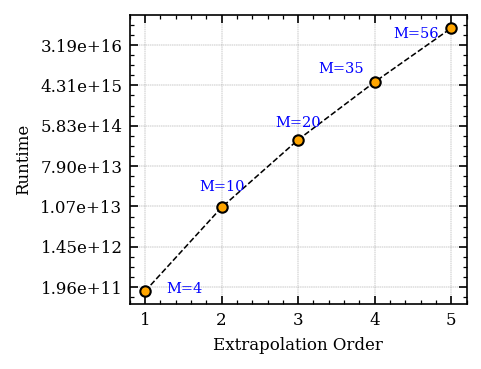

In [31]:
def plot_total_Tmax_vs_order(runtime_per_order: dict, order_M: dict, dpi=150, dpi_600=600, REPORT_DIR="."):
    "Total T_max is the runtime"
    orders = sorted(runtime_per_order.keys())
    totals = [runtime_per_order[o] for o in orders]
    runtime_log = np.log(totals)
    M_values = [order_M[o] for o in orders]

    fig, ax = plt.subplots(figsize=(3.25, 2.5), dpi=dpi)

    ax.plot(
        orders,
        runtime_log,
        marker="o",
        linewidth=0.75,
        markersize=5,
        color="black",
        linestyle="--",
        markerfacecolor="orange",
        markeredgecolor="black",
        markeredgewidth=1.0
        )

    label_offsets = {
        1: ((10, 1), "left"),
        2: ((0, 10), "center"),
        3: ((0, 8), "center"),
        4: ((-5, 6), "right"),
        5: ((-6, -3), "right"),
    }

    for x, y, m in zip(orders, runtime_log, M_values):
        (dx, dy), ha = label_offsets.get(x, ((0, 10), "center"))
        ax.annotate(
            f"M={m}",
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=ha,
            va="center",
            fontsize=7,
            color="blue",
            clip_on=False,
            zorder=5
        )

    ax.set_xlabel("Extrapolation Order", fontsize=8)
    ax.set_ylabel("Runtime", fontsize=8)
    ax.set_xticks(orders)
    ax.grid(True, color='grey', linestyle='--', linewidth=0.2)

    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{np.exp(y):.2e}"))

    fig.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, f"runtime_{nqubits}q_{noise_type}.png"), format="png", dpi=dpi_600)
    plt.show()
    return fig


# --- Usage ---
order_M = {1: 4, 2: 10, 3: 20, 4: 35, 5: 56}  # adjust if your M values differ
fig = plot_total_Tmax_vs_order(runtime_by_zne_order, order_M, REPORT_DIR=REPORT_DIR)

#### Formated values

In [32]:
# runtime_per_order
formatted_runtime_per_order = {k: f"{v:.4e}" for k, v in runtime_by_zne_order.items()}
print(formatted_runtime_per_order)

{1: '1.5998e+11', 2: '1.0172e+13', 3: '2.9154e+14', 4: '5.1022e+15', 5: '7.3544e+16'}


## Computational Cost

In [33]:
# Measurements for VQE gradient
Q_time = 2 * (4**mod_c_dash) * grp_pauli * len_time_param
Q_angle =  2 * len_angle_param * grp_pauli
Q_grad = Q_time + Q_angle
print(f"Total number of VQE measurements required for gradient computation per optimization iteration: {Q_grad:.0f}")

Total number of VQE measurements required for gradient computation per optimization iteration: 8160


In [34]:
comp_cost_vqe = nit_mean * Q_grad * shot_num_su * vqe_total_gate_count
print(f"VQE computation cost: {comp_cost_vqe:.2e}")

VQE computation cost: 3.41e+15


In [35]:
total_gates_per_layer_by_zne_order

{2: 616, 1: 174, 5: 6282, 3: 1554, 4: 3302}

In [36]:
# Total number of gate operation in all layers across all circuits for each ZNE order
total_gates_all_layer_by_zne_order = {
    order : total_gates_per_layer_by_zne_order[order]*layer_num for order in total_gates_per_layer_by_zne_order
}
print(f"Total gates across all layers by ZNE order: {total_gates_all_layer_by_zne_order}")

Total gates across all layers by ZNE order: {2: 18480, 1: 5220, 5: 188460, 3: 46620, 4: 99060}


In [37]:
# Total ZNE computation cost by order
zne_comp_cost_by_order = {
    order: grp_pauli * (shot_num_su * sampling_overhead_eq_by_order[order]) * total_gates_all_layer_by_zne_order[order] for order in zne_overhead_stats
}
print(f"ZNE computation cost by order: {zne_comp_cost_by_order}")
formatted_comp_cost_per_order = {k: f"{v:.4e}" for k, v in zne_comp_cost_by_order.items()}
print(formatted_comp_cost_per_order)

ZNE computation cost by order: {1: 3621086287566.935, 2: 257401810132359.78, 3: 8036907954994026.0, 4: 1.5202148782650115e+17, 5: 2.3569128002160635e+18}
{1: '3.6211e+12', 2: '2.5740e+14', 3: '8.0369e+15', 4: '1.5202e+17', 5: '2.3569e+18'}


In [38]:
comp_cost_total_by_zne_order = {
    order: comp_cost_vqe + zne_comp_cost_by_order[order] for order in zne_comp_cost_by_order
}
print(f"Total computation cost by ZNE order: {comp_cost_total_by_zne_order}")
formatted_total_comp_cost_per_order = {k: f"{v:.4e}" for k, v in comp_cost_total_by_zne_order.items()}
print(formatted_total_comp_cost_per_order)

Total computation cost by ZNE order: {1: 3412565230993536.0, 2: 3666345954838329.0, 3: 1.1445852099699996e+16, 4: 1.5543043197120714e+17, 5: 2.3603217443607695e+18}
{1: '3.4126e+15', 2: '3.6663e+15', 3: '1.1446e+16', 4: '1.5543e+17', 5: '2.3603e+18'}


### 🌟 Plot: Computational Cost vs Extrapolation Order

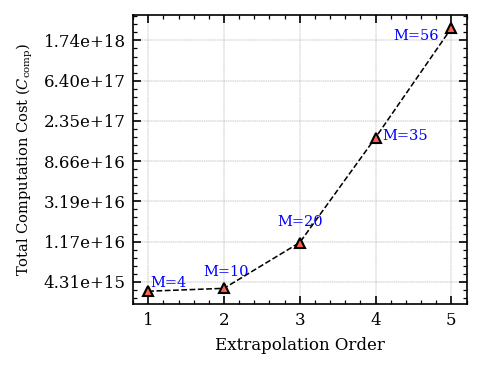

In [39]:
def plot_comp_cost_vs_order(comp_cost_per_order: dict, M_values: dict, dpi=150, REPORT_DIR="."):
    orders = sorted(comp_cost_per_order.keys())
    costs = [comp_cost_per_order[o] for o in orders]
    costs_log = np.log(costs)
    m_vals = [M_values[o] for o in orders]

    fig, ax = plt.subplots(figsize=(3.25, 2.5), dpi=dpi)

    ax.plot(
        orders,
        #costs,
        costs_log,
        marker="^",
        linewidth=0.75,
        markersize=5,
        color="black",
        linestyle="--",
        markerfacecolor="tomato",
        markeredgecolor="black",
        markeredgewidth=1.0
        )

    # Manually tuned offsets (dx, dy in points) and alignment per point,
    # chosen based on the local slope of the curve so labels don't cross the line
    label_offsets = {
        1: ((1,4), "left"),
        2: ((1, 8), "center"),
        3: ((0, 10), "center"),
        4: ((25, 1), "right"),
        5: ((-6, -4), "right"),
    }

    for x, y, m in zip(orders, costs_log, m_vals):
        (dx, dy), ha = label_offsets.get(x, ((0, 10), "center"))
        ax.annotate(
            f"M={m}",
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=ha,
            va="center",
            fontsize=7,
            color="blue",
            clip_on=False,
            zorder=5
        )

    ax.set_xlabel("Extrapolation Order", fontsize=8)
    ax.set_ylabel(r"Total Computation Cost ($C_{\text{comp}})$", fontsize=7)
    ax.set_xticks(orders)
    ax.grid(True, color='grey', linestyle='--', linewidth=0.2)

    # ax.set_xlim(min(orders) - 0.4, max(orders) + 0.4)
    # y_range = max(costs) - min(costs)
    # ax.set_ylim(min(costs) - 0.08 * y_range, max(costs) + 0.10 * y_range)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{np.exp(y):.2e}"))

    fig.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, f"comp_vs_order_{nqubits}q_{noise_type}.png"), format="png", dpi=dpi_600)
    plt.show()
    return fig


# --- Usage ---
M_values = {1: 4, 2: 10, 3: 20, 4: 35, 5: 56}  # adjust to your actual M per order
fig = plot_comp_cost_vs_order(comp_cost_total_by_zne_order, M_values, REPORT_DIR=REPORT_DIR)

In [40]:
vqe_noise_off_mean: float = PROCESSED_SIM_DATA[_QSYSTEM]["VQE_noiseoff"]["fun_mean"]
print(f"Mean VQE noise-off value: {vqe_noise_off_mean:.6f}")
vqe_noise_off_std: float = PROCESSED_SIM_DATA[_QSYSTEM]["VQE_noiseoff"]["fun_std"]
print(f"Std VQE noise-off value: {vqe_noise_off_std:.6f}")

Mean VQE noise-off value: -9.658448
Std VQE noise-off value: 0.052869


In [41]:
zne_var_data = PROCESSED_SIM_DATA[_QSYSTEM]["ZNE-mul-var"]

error_rate_with_std_per_zne_order = {
    order: {
        "error_rate":     abs(zne_var_data[f"muld{order}"]["zne_mean"] - vqe_noise_off_mean),
        "error_rate_std": np.hypot(zne_var_data[f"muld{order}"]["zne_std"], vqe_noise_off_std),
    }
    for order in orders
}
print(f"Error with std per ZNE order: {error_rate_with_std_per_zne_order}")

Error with std per ZNE order: {1: {'error_rate': 0.8423516308092118, 'error_rate_std': 0.13513855193115692}, 2: {'error_rate': 0.2927385082457068, 'error_rate_std': 0.10656146326953847}, 3: {'error_rate': 0.13404973739594794, 'error_rate_std': 0.09292386227534674}, 4: {'error_rate': 0.11351176519377049, 'error_rate_std': 0.08752440778513228}, 5: {'error_rate': 0.14477679622449635, 'error_rate_std': 0.08612756554332295}}


In [42]:
# error = | noise-off vqe - zne at a given order |
error_rate_per_zne_order = {
    order: error_rate_with_std_per_zne_order[order]["error_rate"]
    for order in orders
}
print(f"Error per ZNE order: {error_rate_per_zne_order}")

Error per ZNE order: {1: 0.8423516308092118, 2: 0.2927385082457068, 3: 0.13404973739594794, 4: 0.11351176519377049, 5: 0.14477679622449635}


### 🌟 Plot: Computational Cost vs Error

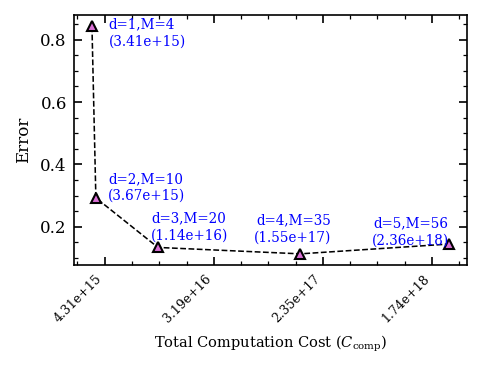

In [43]:
def plot_cost_vs_error_tradeoff(comp_cost_per_order: dict, error_rate_per_zne_order: dict, M_values: dict,
                                  fig_width=4, dpi=150, dpi_600=600, REPORT_DIR="."):
    orders = sorted(comp_cost_per_order.keys())
    costs = [comp_cost_per_order[o] for o in orders]
    costs_log = np.log(costs)
    errors = [error_rate_per_zne_order[o] for o in orders]
    m_vals = [M_values[o] for o in orders]

    fig, ax = plt.subplots(figsize=(3.25, 2.5), dpi=dpi)

    ax.plot(
        costs_log,
        errors,
        marker="^",
        linewidth=0.75,
        markersize=5,
        color="black",
        linestyle="--",
        markerfacecolor="orchid",
        markeredgecolor="black",
        markeredgewidth=1.0
        )

    # Manually tuned offsets (dx, dy in points) and alignment per point,
    label_offsets = {
        1: ((8, -3), "left"),
        2: ((6, 5), "left"),
        3: ((15, 10), "center"),
        4: ((15, 12), "right"),
        5: ((0, 6), "right"),
    }

    for order, M, x, y, m, c in zip(orders, m_vals, costs_log, errors, m_vals, costs):
        (dx, dy), ha = label_offsets.get(order, ((0, 10), "center"))
        ax.annotate(
            f"d={order},M={M}\n({c:.2e})",
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=ha,
            va="center",
            fontsize=6.5,
            color="blue",
            linespacing=1.3,
            clip_on=False,
            zorder=5
        )
        
    ax.set_xlabel(r"Total Computation Cost ($C_{\text{comp}})$", fontsize=7)
    ax.set_ylabel("Error", fontsize=8)
    #ax.grid(True, color='grey', linestyle='--', linewidth=0.2)

    # Cost and error typically span orders of magnitude here — log scale keeps
    # low-order points from being crushed against the axes.
    #ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.xaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{np.exp(y):.2e}"))
    # Rotate labels so they don't overlap
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)
    fig.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, f"err_vs_comp_{nqubits}q_{noise_type}.png"), format="png", dpi=dpi_600)
    plt.show()
    return fig


# --- Usage ---
M_values = {1: 4, 2: 10, 3: 20, 4: 35, 5: 56}  # adjust to your actual M per order
fig = plot_cost_vs_error_tradeoff(comp_cost_total_by_zne_order, error_rate_per_zne_order, M_values, REPORT_DIR=REPORT_DIR)

### 🌟 Plot: ZNE Computational Cost vs Extrapolation Order

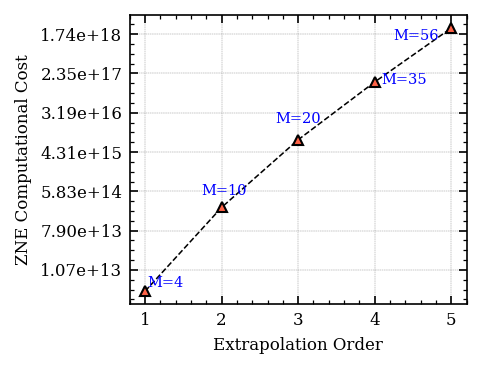

In [44]:
def plot_zne_comp_cost_vs_order(zne_cost_per_order: dict, M_values: dict, dpi=150, REPORT_DIR="."):
    orders = sorted(zne_cost_per_order.keys())
    costs = [zne_cost_per_order[o] for o in orders]
    costs_log = np.log(costs)
    m_vals = [M_values[o] for o in orders]

    fig, ax = plt.subplots(figsize=(3.25, 2.5), dpi=dpi)

    ax.plot(
        orders,
        #costs,
        costs_log,
        marker="^",
        linewidth=0.75,
        markersize=5,
        color="black",
        linestyle="--",
        markerfacecolor="tomato",
        markeredgecolor="black",
        markeredgewidth=1.0
        )

    # Manually tuned offsets (dx, dy in points) and alignment per point,
    # chosen based on the local slope of the curve so labels don't cross the line
    label_offsets = {
        1: ((1,4), "left"),
        2: ((1, 8), "center"),
        3: ((0, 10), "center"),
        4: ((25, 1), "right"),
        5: ((-6, -4), "right"),
    }

    for x, y, m in zip(orders, costs_log, m_vals):
        (dx, dy), ha = label_offsets.get(x, ((0, 10), "center"))
        ax.annotate(
            f"M={m}",
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=ha,
            va="center",
            fontsize=7,
            color="blue",
            clip_on=False,
            zorder=5
        )

    ax.set_xlabel("Extrapolation Order", fontsize=8)
    ax.set_ylabel("ZNE Computational Cost", fontsize=8)
    ax.set_xticks(orders)
    ax.grid(True, color='grey', linestyle='--', linewidth=0.2)

    # ax.set_xlim(min(orders) - 0.4, max(orders) + 0.4)
    # y_range = max(costs) - min(costs)
    # ax.set_ylim(min(costs) - 0.08 * y_range, max(costs) + 0.10 * y_range)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{np.exp(y):.2e}"))

    fig.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, f"zne_comp_vs_order_{nqubits}q_{noise_type}.png"), format="png", dpi=dpi_600)
    plt.show()
    return fig


# --- Usage ---
M_values = {1: 4, 2: 10, 3: 20, 4: 35, 5: 56}  # adjust to your actual M per order
fig = plot_zne_comp_cost_vs_order(zne_comp_cost_by_order, M_values, REPORT_DIR=REPORT_DIR)

### 🌟 Plot: ZNE Computational Cost vs Error

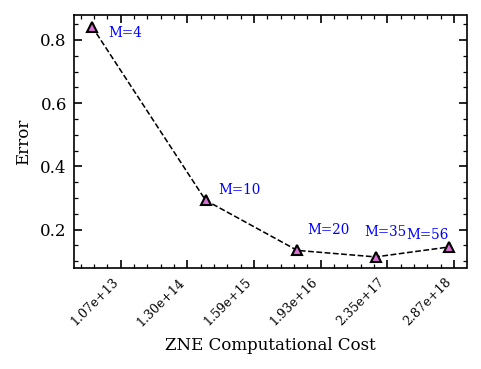

In [45]:
def plot_cost_vs_error_tradeoff(comp_cost_per_order: dict, error_rate_per_zne_order: dict, M_values: dict,
                                  fig_width=4, dpi=150, dpi_600=600, REPORT_DIR=".", filename=None):
    orders = sorted(comp_cost_per_order.keys())
    costs = [comp_cost_per_order[o] for o in orders]
    costs_log = np.log(costs)
    errors = [error_rate_per_zne_order[o] for o in orders]
    m_vals = [M_values[o] for o in orders]

    fig, ax = plt.subplots(figsize=(3.25, 2.5), dpi=dpi)

    ax.plot(
        costs_log,
        errors,
        marker="^",
        linewidth=0.75,
        markersize=5,
        color="black",
        linestyle="--",
        markerfacecolor="orchid",
        markeredgecolor="black",
        markeredgewidth=1.0
        )

    # Manually tuned offsets (dx, dy in points) and alignment per point,
    label_offsets = {
        1: ((8, -3), "left"),
        2: ((6, 5), "left"),
        3: ((15, 10), "center"),
        4: ((15, 12), "right"),
        5: ((0, 6), "right"),
    }

    for order, M, x, y, m, c in zip(orders, m_vals, costs_log, errors, m_vals, costs):
        (dx, dy), ha = label_offsets.get(order, ((0, 10), "center"))
        ax.annotate(
            f"M={M}",
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=ha,
            va="center",
            fontsize=6.5,
            color="blue",
            linespacing=1.3,
            clip_on=False,
            zorder=5
        )

    ax.set_xlabel("ZNE Computational Cost", fontsize=8)
    ax.set_ylabel("Error", fontsize=8)
    #ax.grid(True, color='grey', linestyle='--', linewidth=0.2)

    # Cost and error typically span orders of magnitude here — log scale keeps
    # low-order points from being crushed against the axes.
    #ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.xaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{np.exp(y):.2e}"))
    # Rotate labels so they don't overlap
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)
    fig.tight_layout()

    if filename is None:
        filename = f"err_vs_comp_{nqubits}q_{noise_type}.png"

    plt.savefig(os.path.join(REPORT_DIR, filename), format="png", dpi=dpi_600)
    plt.show()
    return fig


# --- Usage ---
M_values = {1: 4, 2: 10, 3: 20, 4: 35, 5: 56} 


fig = plot_cost_vs_error_tradeoff(
    zne_comp_cost_by_order, error_rate_per_zne_order, M_values,
    REPORT_DIR=REPORT_DIR, filename=f"zne_err_vs_comp_{nqubits}q_{noise_type}.png"
)

---
# JSON For Latex Tools

In [46]:
_NOISE_TYPE_LABELS = {
    "time-depol":     "Depolarizing",
    "time-dephasing": "Dephasing",
    "time-ampdamp":   "AD",
}

raw_noise_type = PROCESSED_SIM_DATA[_QSYSTEM]["ZNE-mul-var"]["muld1"]["noise_type"]
noise_type_label= _NOISE_TYPE_LABELS.get(raw_noise_type, raw_noise_type)

ORDERS = [1, 2, 3, 4, 5]

zne_var_data = PROCESSED_SIM_DATA[_QSYSTEM]["ZNE-mul-var"]
base = zne_var_data["muld1"]

rows = []
for order in ORDERS:
    key = f"muld{order}"
    d = zne_var_data[key]

    rows.append({
        "order": order,
        "zne_mean": d["zne_mean"],
        "zne_std": d["zne_std"],
        "error_rate": error_rate_with_std_per_zne_order[order],
        "runtime": runtime_by_zne_order[order],
        "comp_cost": comp_cost_total_by_zne_order[order],
        "depth": depth_per_layer_by_zne_order[order],
        "gate": total_gates_per_layer_by_zne_order[order],
        "overhead": d.get("cost_eq_mean"),
    })

export_data = {
    "noise_model": noise_type_label,
    "unmitigated_mean": base["mean_exp_vals"][0],
    "unmitigated_std": base["std_exp_vals"][0],
    "noise_free_mean": base["mean_noise_off"],
    "noise_free_std": base["std_noise_off"],
    "rows": rows,
}

out_path = f"{REPORT_DIR}/zne_multivar_{noise_type_label.lower()}.json"
with open(out_path, "w") as f:
    json.dump(export_data, f, indent=2)

print(f"Exported to {out_path}")
export_data

Exported to reports/8Q-ising-depol//zne_multivar_depolarizing.json


{'noise_model': 'Depolarizing',
 'unmitigated_mean': -7.028104805115262,
 'unmitigated_std': 0.158371805293024,
 'noise_free_mean': -9.65844800304873,
 'noise_free_std': 0.05286937954035172,
 'rows': [{'order': 1,
   'zne_mean': -8.816096372239517,
   'zne_std': 0.12436742710641012,
   'error_rate': {'error_rate': 0.8423516308092118,
    'error_rate_std': 0.13513855193115692},
   'runtime': 159975678708.56924,
   'comp_cost': 3412565230993536.0,
   'depth': 70.0,
   'gate': 174,
   'overhead': 17.5},
  {'order': 2,
   'zne_mean': -9.365709494803022,
   'zne_std': 0.09252120925043855,
   'error_rate': {'error_rate': 0.2927385082457068,
    'error_rate_std': 0.10656146326953847},
   'runtime': 10171794343898.32,
   'comp_cost': 3666345954838329.0,
   'depth': 236.0,
   'gate': 616,
   'overhead': 351.38183593749824},
  {'order': 3,
   'zne_mean': -9.524398265652781,
   'zne_std': 0.07641775243479651,
   'error_rate': {'error_rate': 0.13404973739594794,
    'error_rate_std': 0.09292386227